# Detect irregular predicted CNT objects
This notebook loads CPSAM v2 and NanoVision COCO RLE predictions,
skeletonizes every predicted object, and identifies objects whose
skeleton contains more than two endpoints.
For this initial analysis, an object is considered irregular when:

number of endpoints > 2


In [16]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.morphology import skeletonize


PROJECT_ROOT = next(
    path
    for path in [
        Path.cwd(),
        *Path.cwd().parents,
    ]
    if (path / "pyproject.toml").is_file()
)

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

from cnt_project.features.core.cnt_feature_extraction import (
    decode_annotation_mask,
)

from cnt_project.model_development.postprocessing.filtering.shape_heuristics import (
    count_endpoints,
)
from cnt_project.features.core.tree_length import (
    prune_branches,
    skeleton_graph,
)

print("Current directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)

Current directory: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\stratified_evaluation
Project root: c:\Users\abd93000\PycharmProjects\cnt_project_v2


In [2]:
CPSAM_RLE_JSON = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / "cpsam_v2_legacy_seed42_best_validation_optimized"
    / "inference"
    / "predicted_annotations_rle.json"
)

NANOVISION_RLE_JSON = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / (
        "fluo_edt_edt_score_symmetry_score_"
        "without_smoothing_20260610_1004 - Copy"
    )
    / "inference"
    / "predicted_annotations_rle.json"
)

print("CPSAM exists:", CPSAM_RLE_JSON.is_file())
print(
    "NanoVision exists:",
    NANOVISION_RLE_JSON.is_file(),
)

CPSAM exists: True
NanoVision exists: True


## Irregular-object detection
For every predicted annotation:
1. Decode the COCO RLE segmentation into a binary mask.
2. Skeletonize the mask.
3. Count skeleton pixels having exactly one 8-connected neighbor.
4. Retain the object when it has more than two endpoints.

In [3]:
def find_irregular_predictions(
    json_path,
    model_name,
):
    coco = json.loads(
        json_path.read_text(
            encoding="utf-8-sig"
        )
    )

    images_by_id = {
        int(image["id"]): image
        for image in coco["images"]
    }

    rows = []
    object_data = {}

    for annotation in coco["annotations"]:
        image_id = int(
            annotation["image_id"]
        )

        annotation_id = int(
            annotation["id"]
        )

        image = images_by_id[image_id]

        height = int(image["height"])
        width = int(image["width"])

        mask = decode_annotation_mask(
            annotation,
            height,
            width,
        ).astype(bool)

        skeleton = skeletonize(
            mask
        )

        endpoint_count = count_endpoints(
            skeleton
        )

        if endpoint_count <= 2:
            continue

        object_key = (
            model_name,
            annotation_id,
        )

        rows.append(
            {
                "model": model_name,
                "filename": image["file_name"],
                "image_id": image_id,
                "annotation_id": annotation_id,
                "score": annotation.get(
                    "score",
                    np.nan,
                ),
                "area_px": int(mask.sum()),
                "skeleton_pixels": int(
                    skeleton.sum()
                ),
                "endpoint_count": endpoint_count,
            }
        )

        object_data[object_key] = {
            "mask": mask,
            "skeleton": skeleton,
        }

    return rows, object_data

## Analyze both prediction models

In [4]:
cpsam_rows, cpsam_data = (
    find_irregular_predictions(
        CPSAM_RLE_JSON,
        "CPSAM v2",
    )
)

nanovision_rows, nanovision_data = (
    find_irregular_predictions(
        NANOVISION_RLE_JSON,
        "NanoVision",
    )
)

irregular_objects = pd.DataFrame(
    cpsam_rows + nanovision_rows
)

object_data = {
    **cpsam_data,
    **nanovision_data,
}

print(
    "Irregular objects:",
    len(irregular_objects),
)

display(
    irregular_objects.head()
)

Irregular objects: 766


,model,filename,image_id,annotation_id,score,area_px,skeleton_pixels,endpoint_count
0,CPSAM v2,1293-22_3_2_20230306222551.tif,1,5,NaN,83,23,3
1,CPSAM v2,1293-22_3_2_20230306222551.tif,1,7,NaN,125,25,3
2,CPSAM v2,1293-22_3_2_20230306222551.tif,1,9,NaN,216,60,3
3,CPSAM v2,1293-22_3_2_20230306222551.tif,1,32,NaN,196,43,4
4,CPSAM v2,1293-22_3_2_20230306222551.tif,1,33,NaN,145,32,3


## Summary by model
Compare the number of irregular objects, affected images, and
endpoint counts between CPSAM v2 and NanoVision.

In [5]:
irregular_summary = (
    irregular_objects
    .groupby("model")
    .agg(
        irregular_objects=(
            "annotation_id",
            "count",
        ),
        affected_images=(
            "filename",
            "nunique",
        ),
        mean_endpoints=(
            "endpoint_count",
            "mean",
        ),
        maximum_endpoints=(
            "endpoint_count",
            "max",
        ),
    )
)

display(irregular_summary)

,irregular_objects,affected_images,mean_endpoints,maximum_endpoints
model,,,,
CPSAM v2,426,27,3.281690,8
NanoVision,340,24,3.085294,5


In [7]:
display(
    pd.crosstab(
        irregular_objects["endpoint_count"],
        irregular_objects["model"],
    )
)

model,CPSAM v2,NanoVision
endpoint_count,,
3,326,313
4,86,25
5,10,2
6,3,0
8,1,0


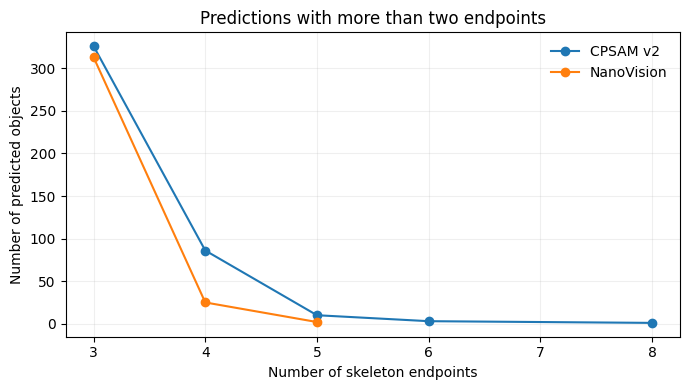

In [8]:
figure, axis = plt.subplots(
    figsize=(7, 4)
)

for model, model_data in (
    irregular_objects.groupby("model")
):
    counts = (
        model_data["endpoint_count"]
        .value_counts()
        .sort_index()
    )

    axis.plot(
        counts.index,
        counts.values,
        marker="o",
        label=model,
    )

axis.set_xlabel("Number of skeleton endpoints")
axis.set_ylabel("Number of predicted objects")
axis.set_title(
    "Predictions with more than two endpoints"
)
axis.grid(alpha=0.2)
axis.legend(frameon=False)

figure.tight_layout()
plt.show()

## Visualize irregular objects
Display an equal number of irregular objects from each model.
- Gray: predicted-object mask
- Cyan: skeleton
- Yellow: detected endpoints
The complete image canvas is retained to show the location and
relative size of each object.

model
CPSAM v2      30
NanoVision    30
Name: count, dtype: int64


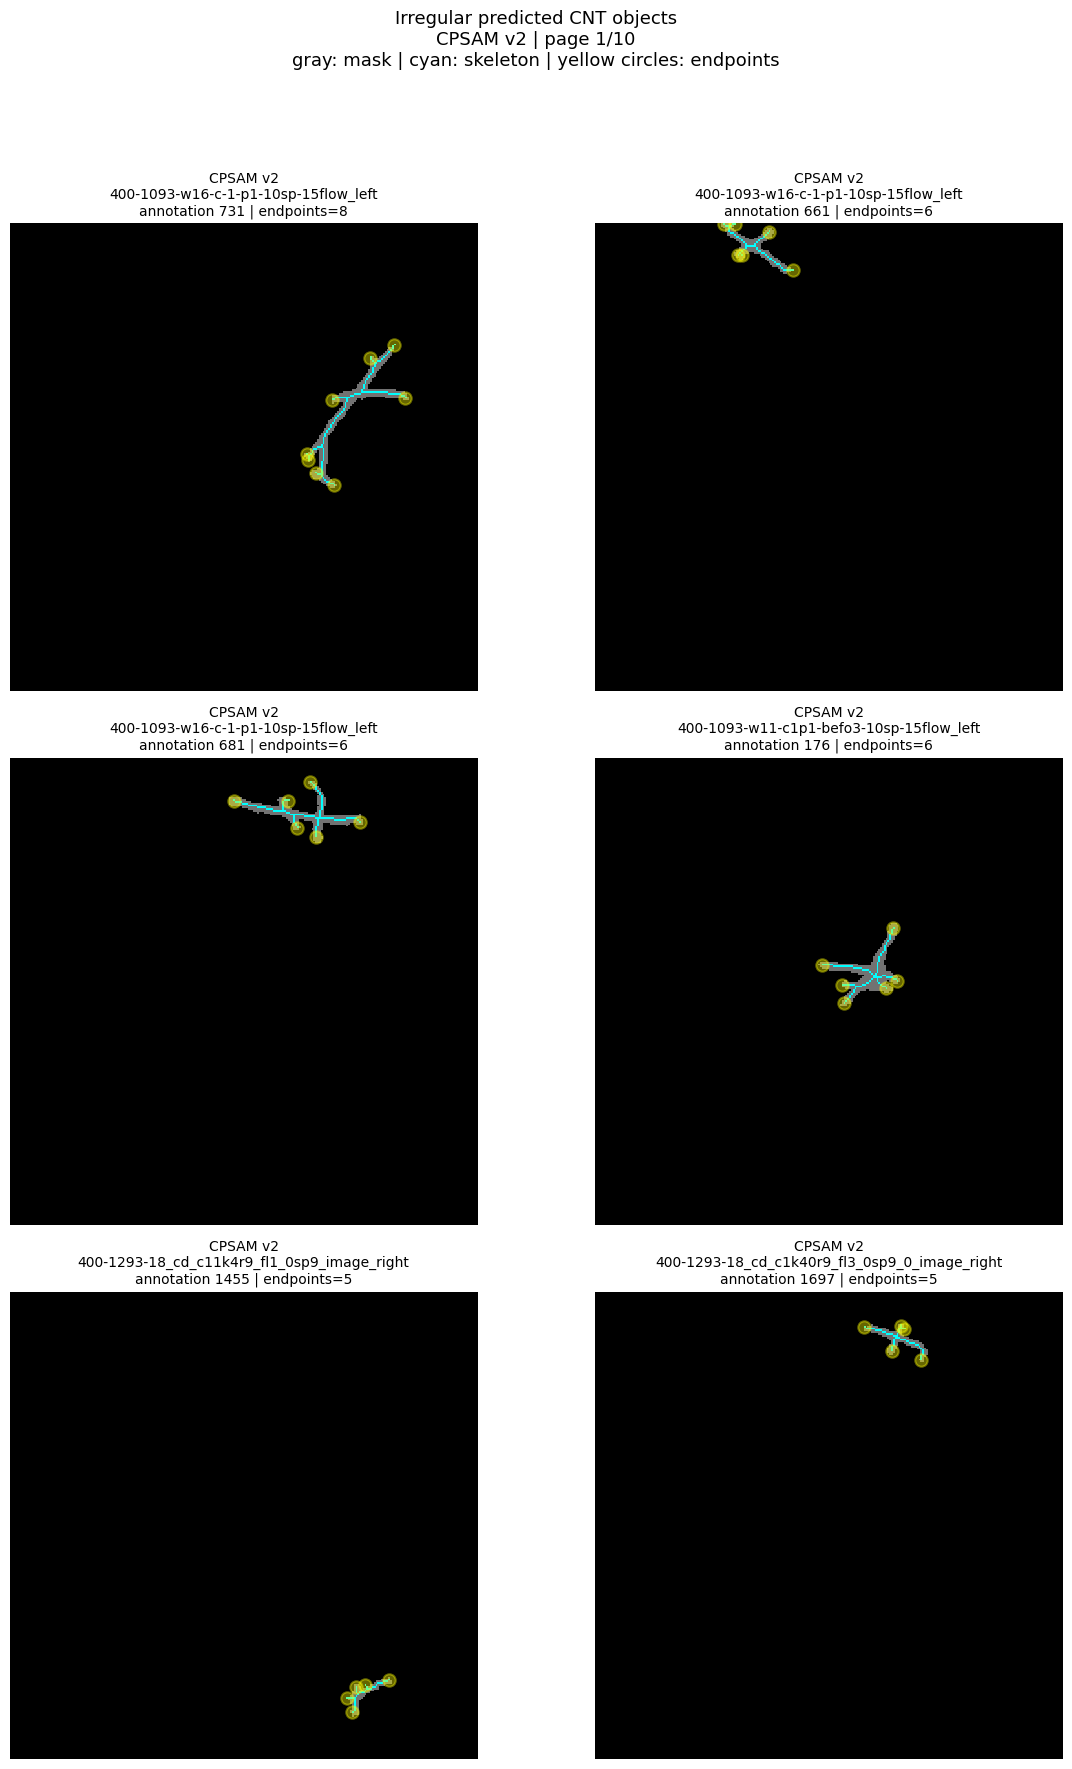

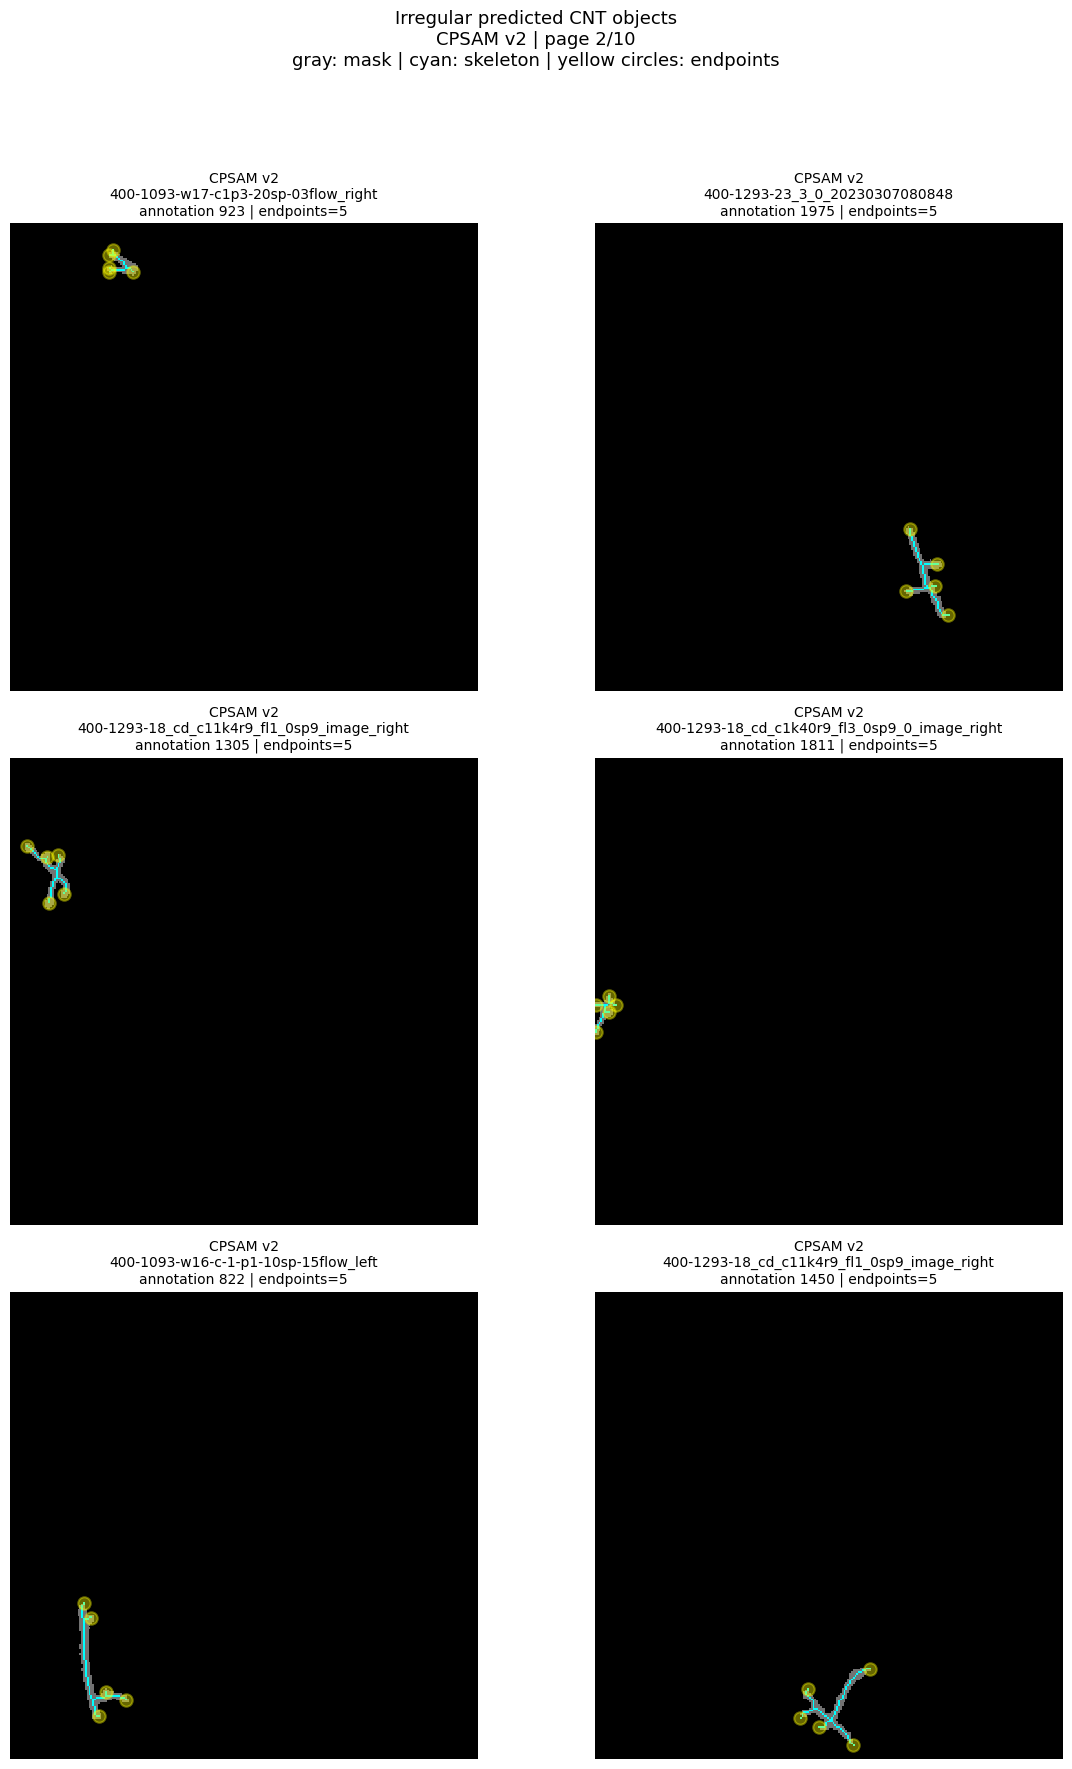

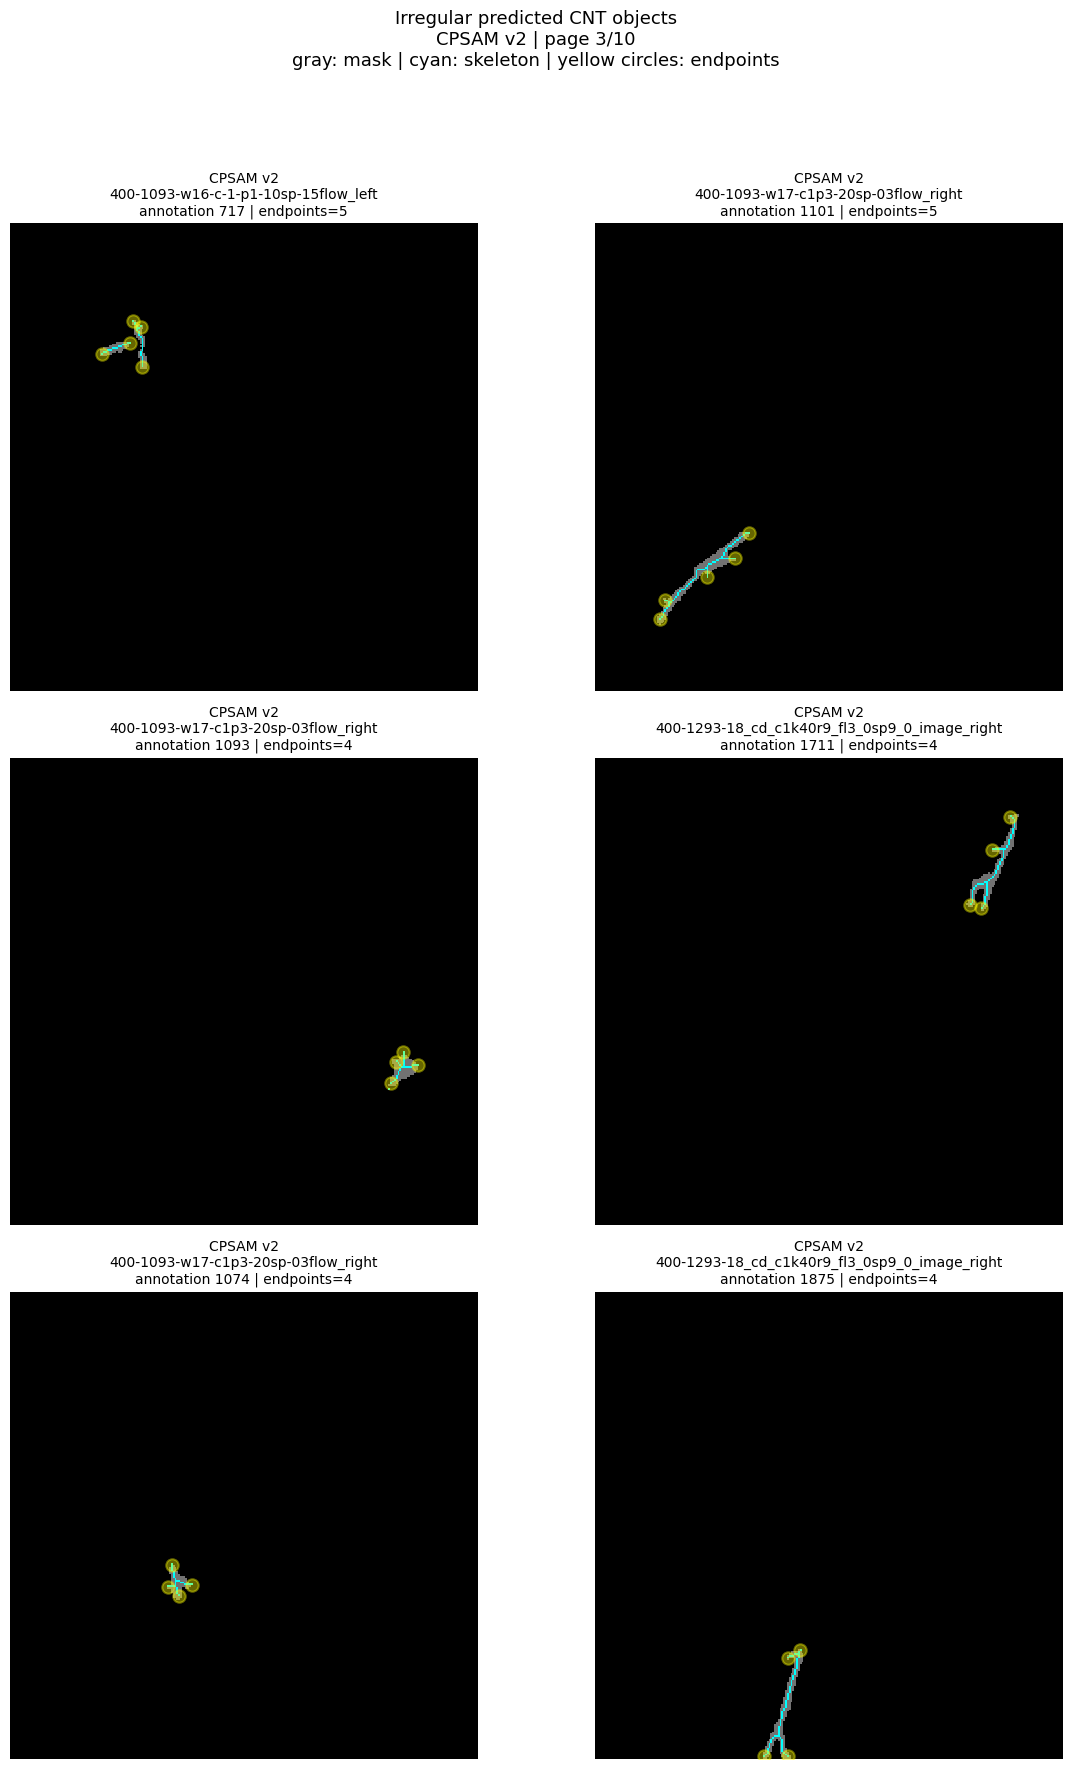

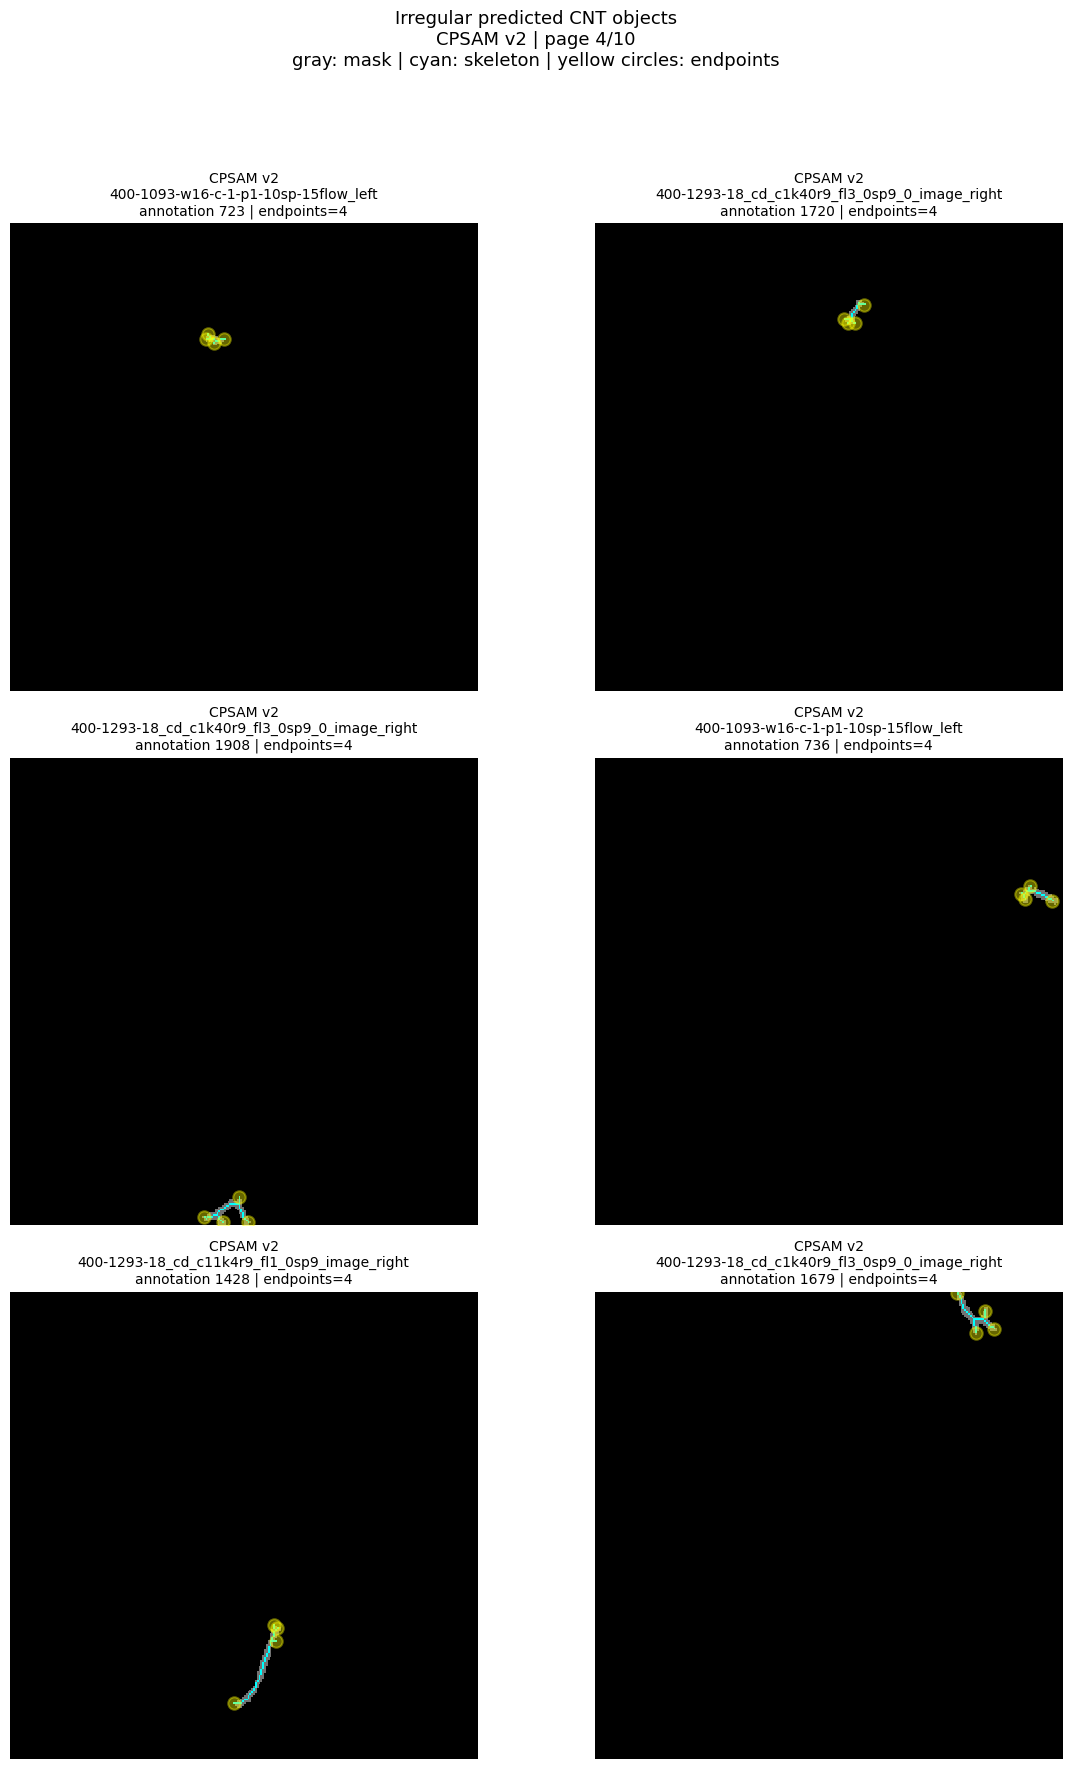

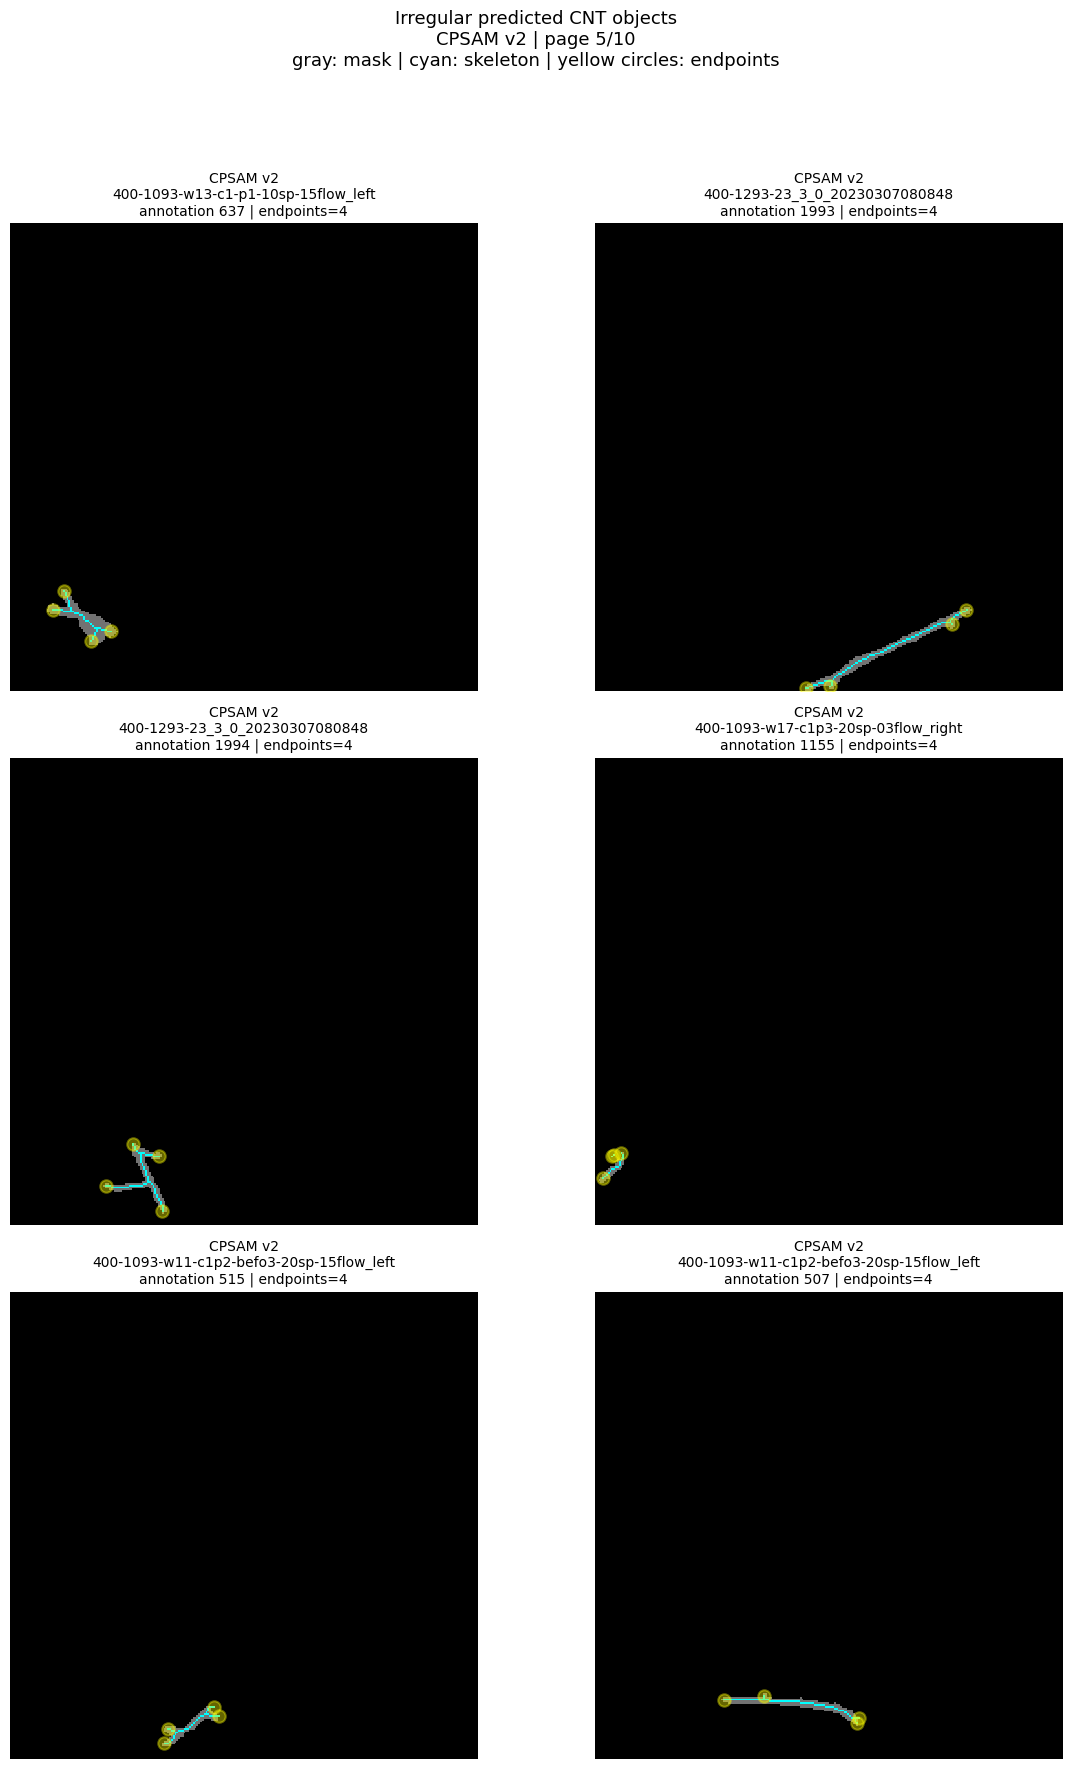

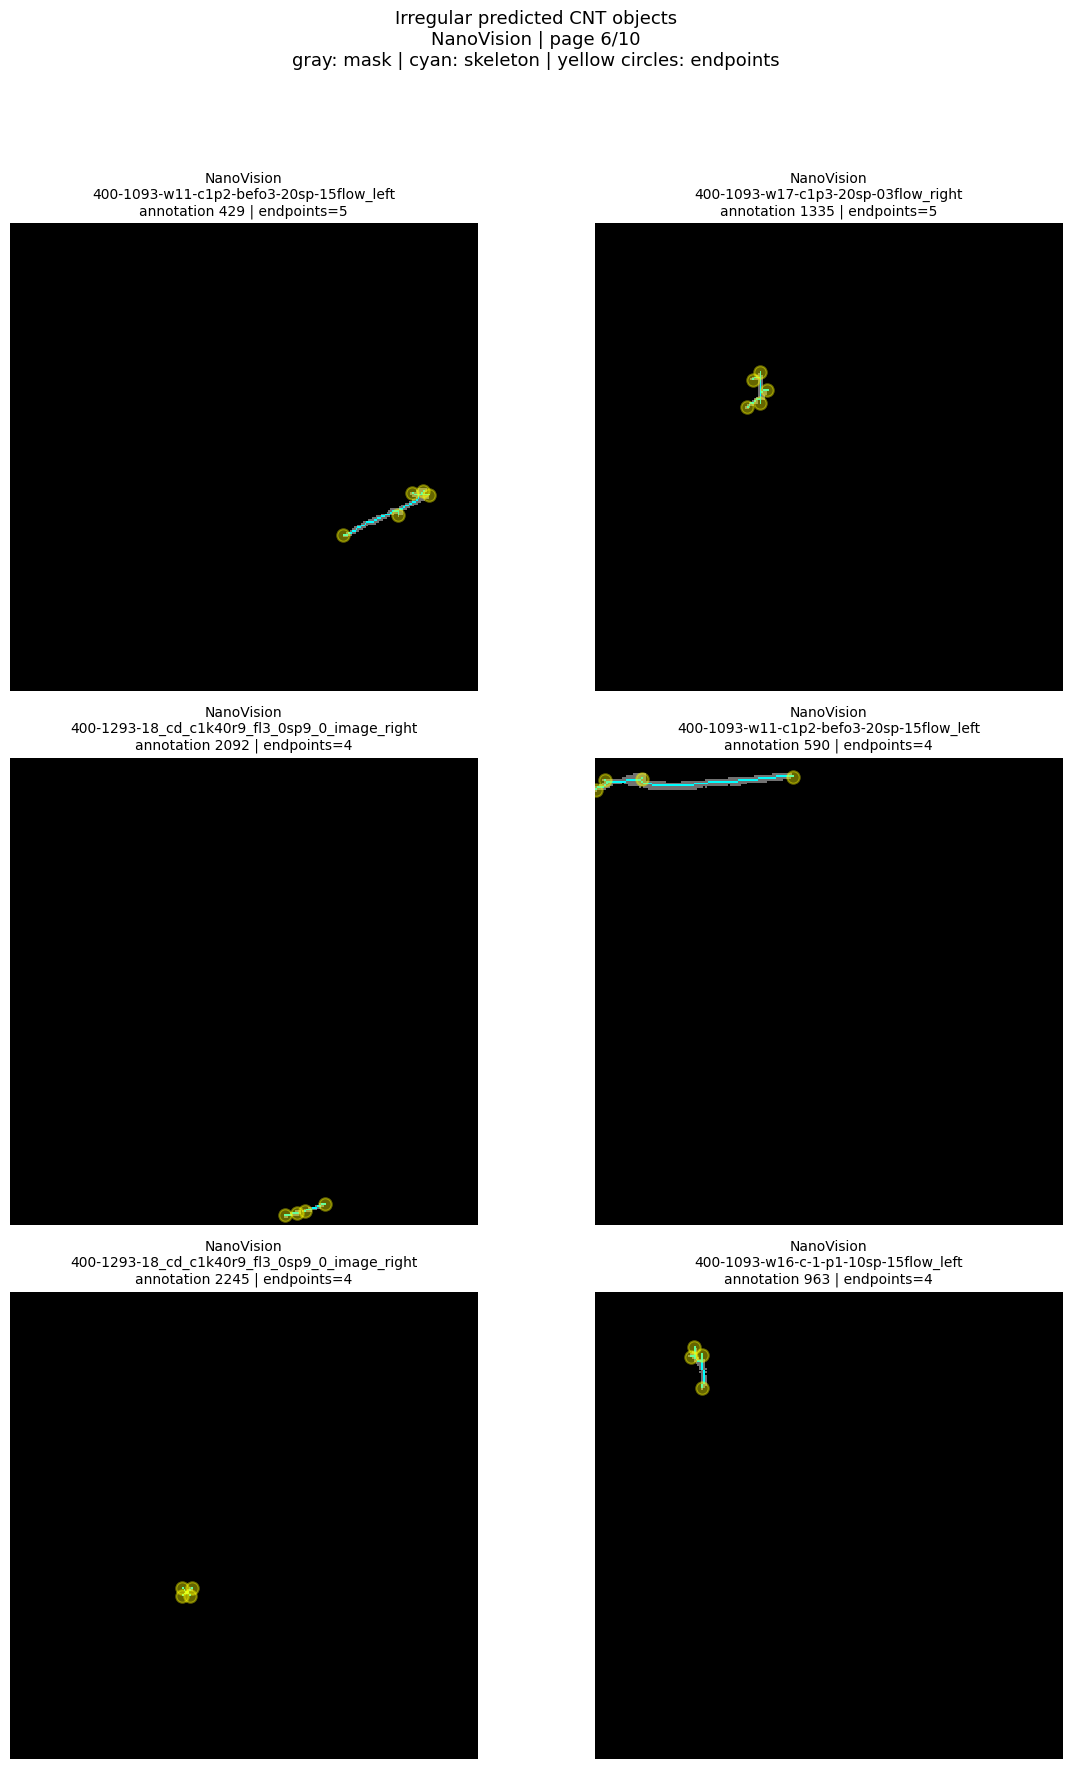

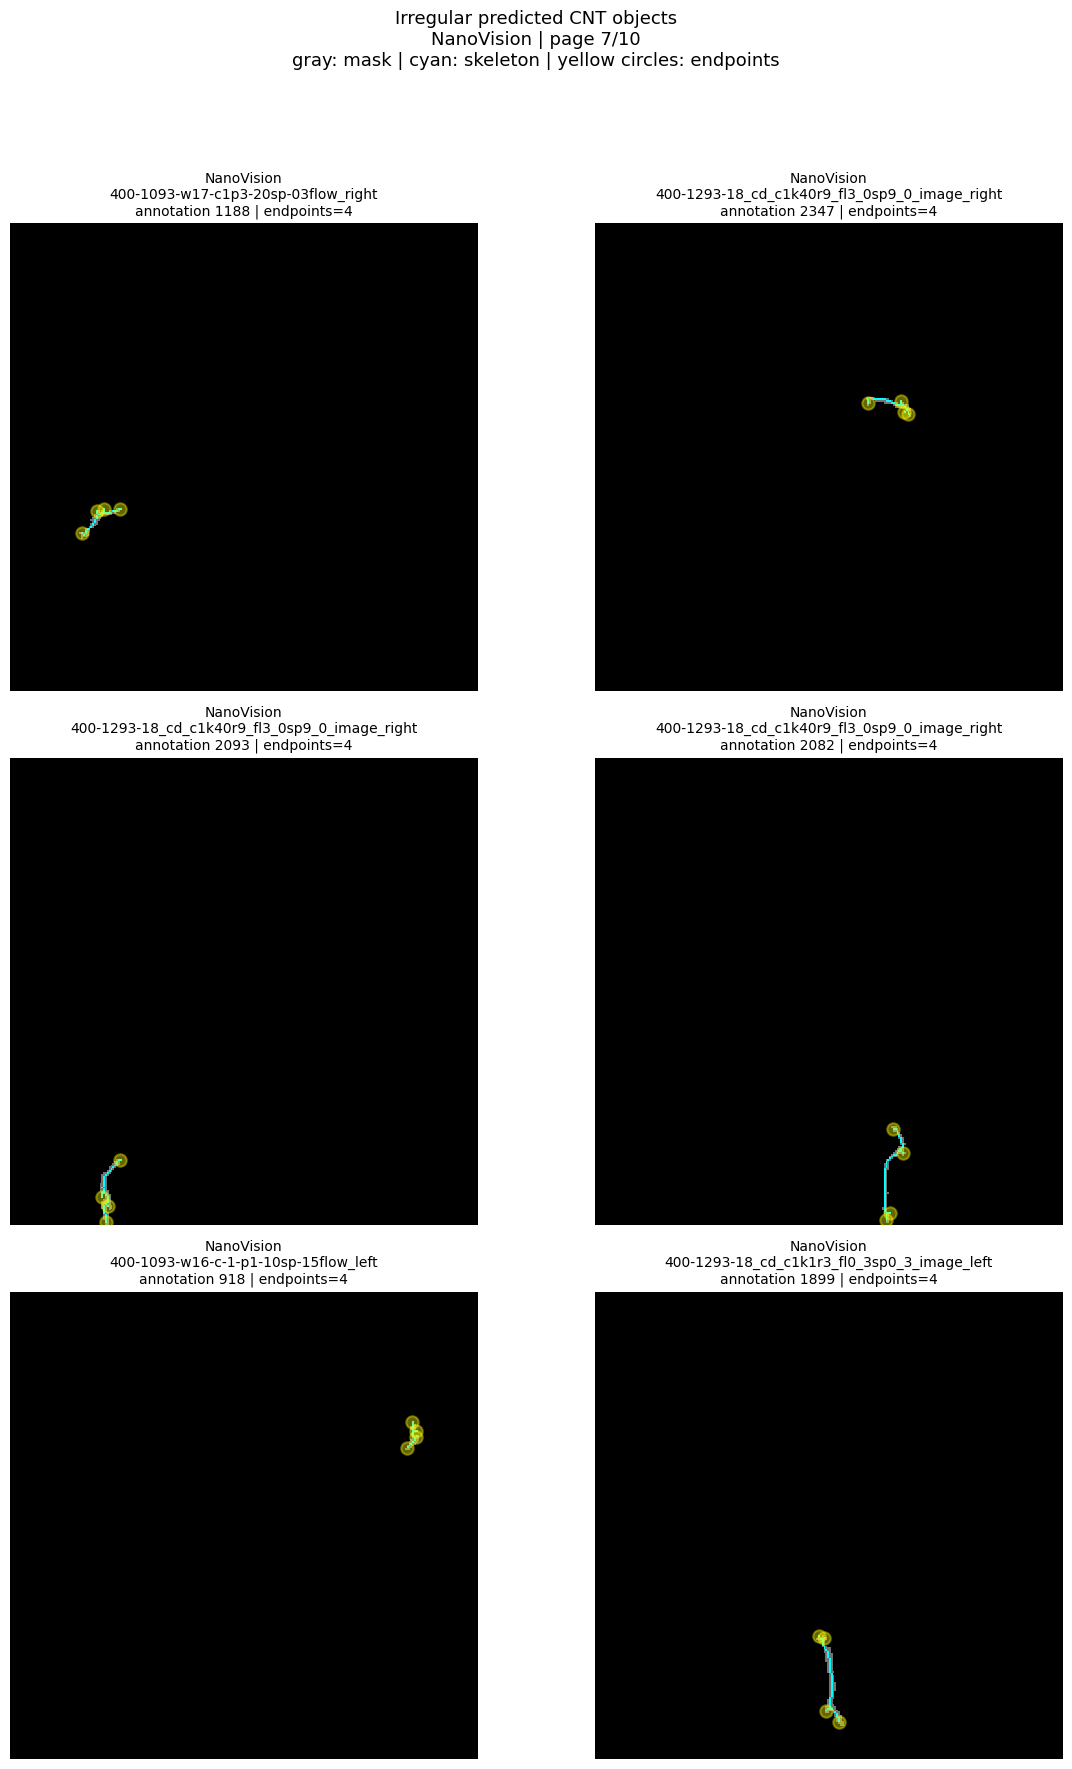

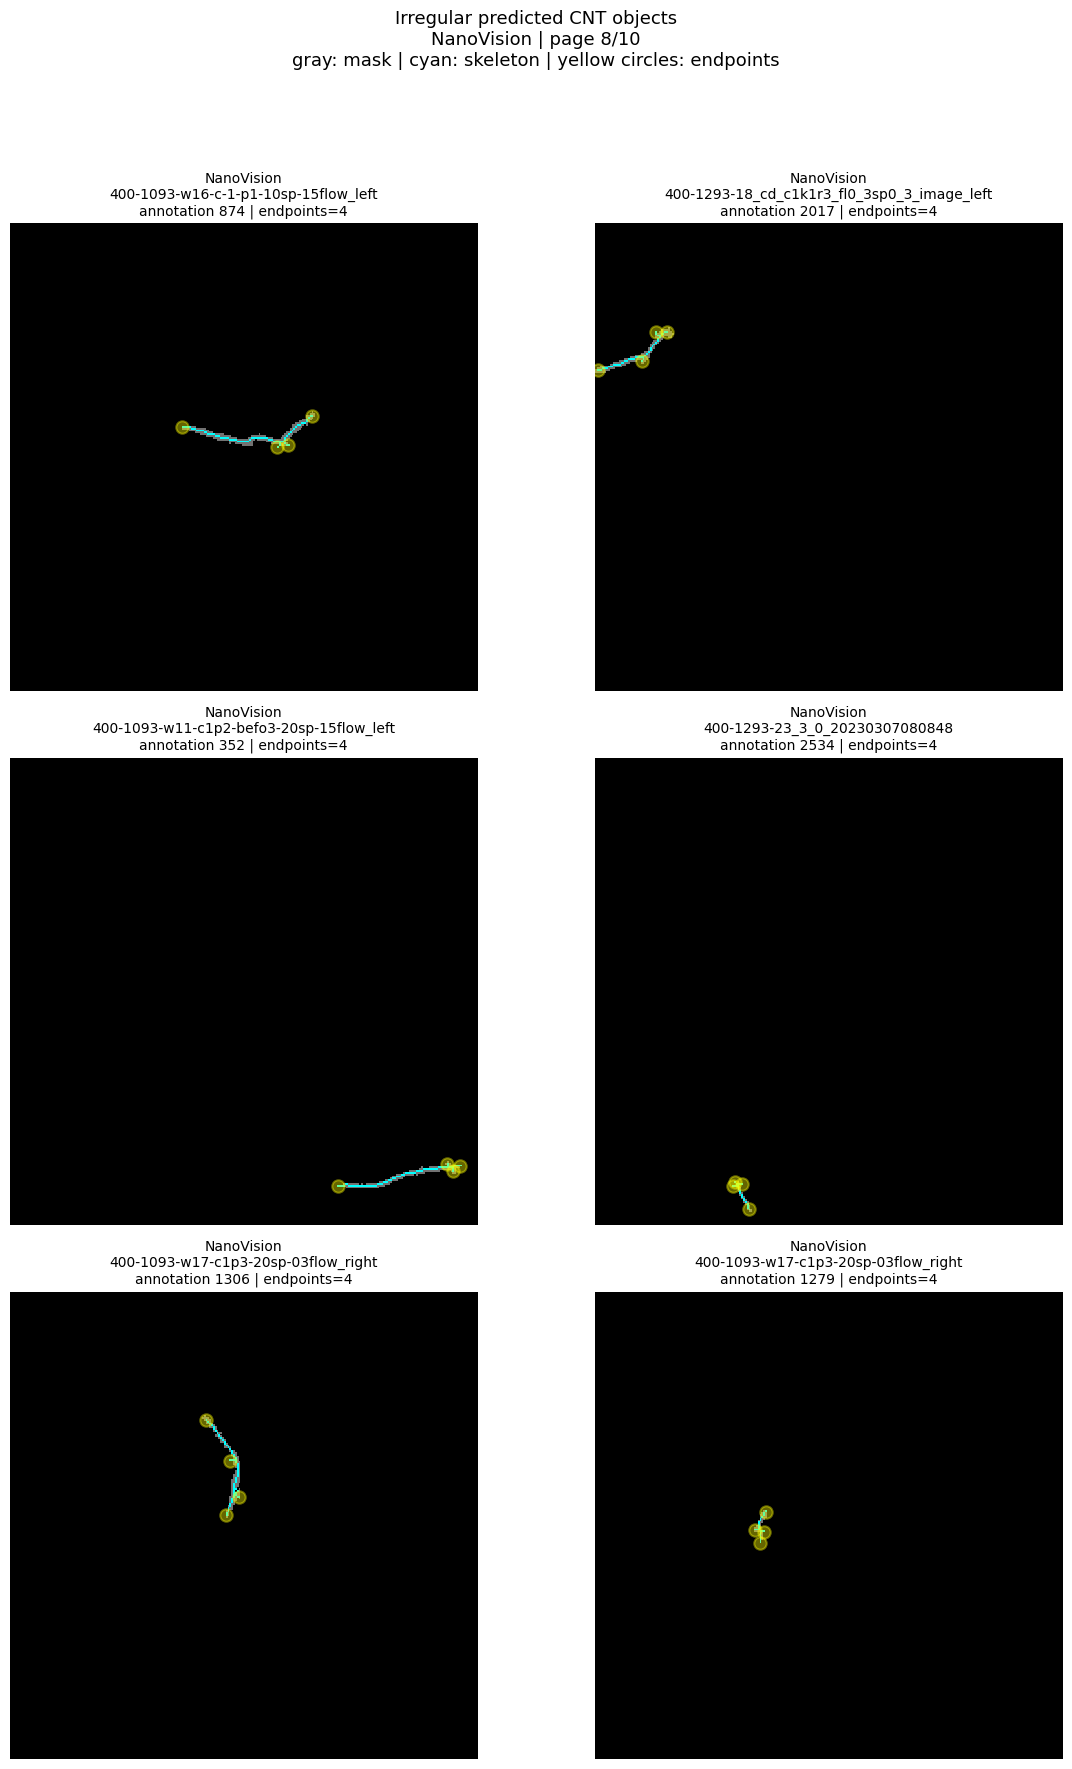

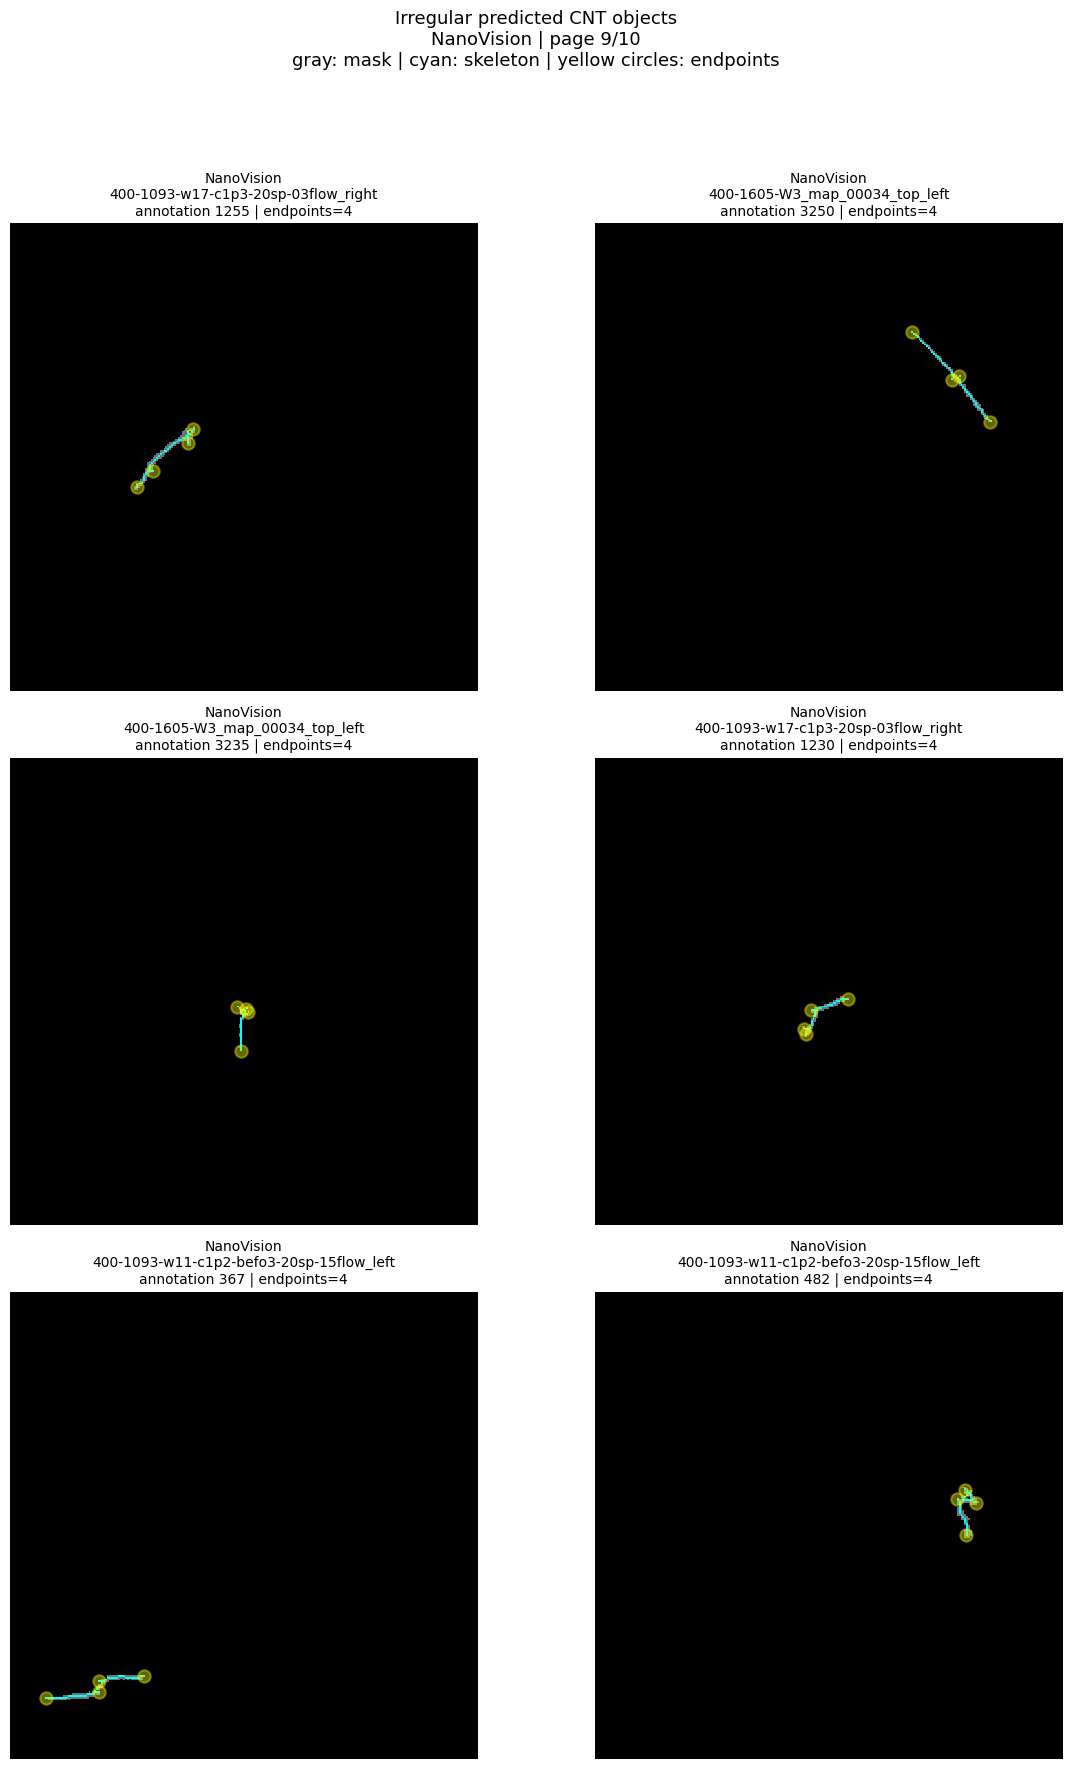

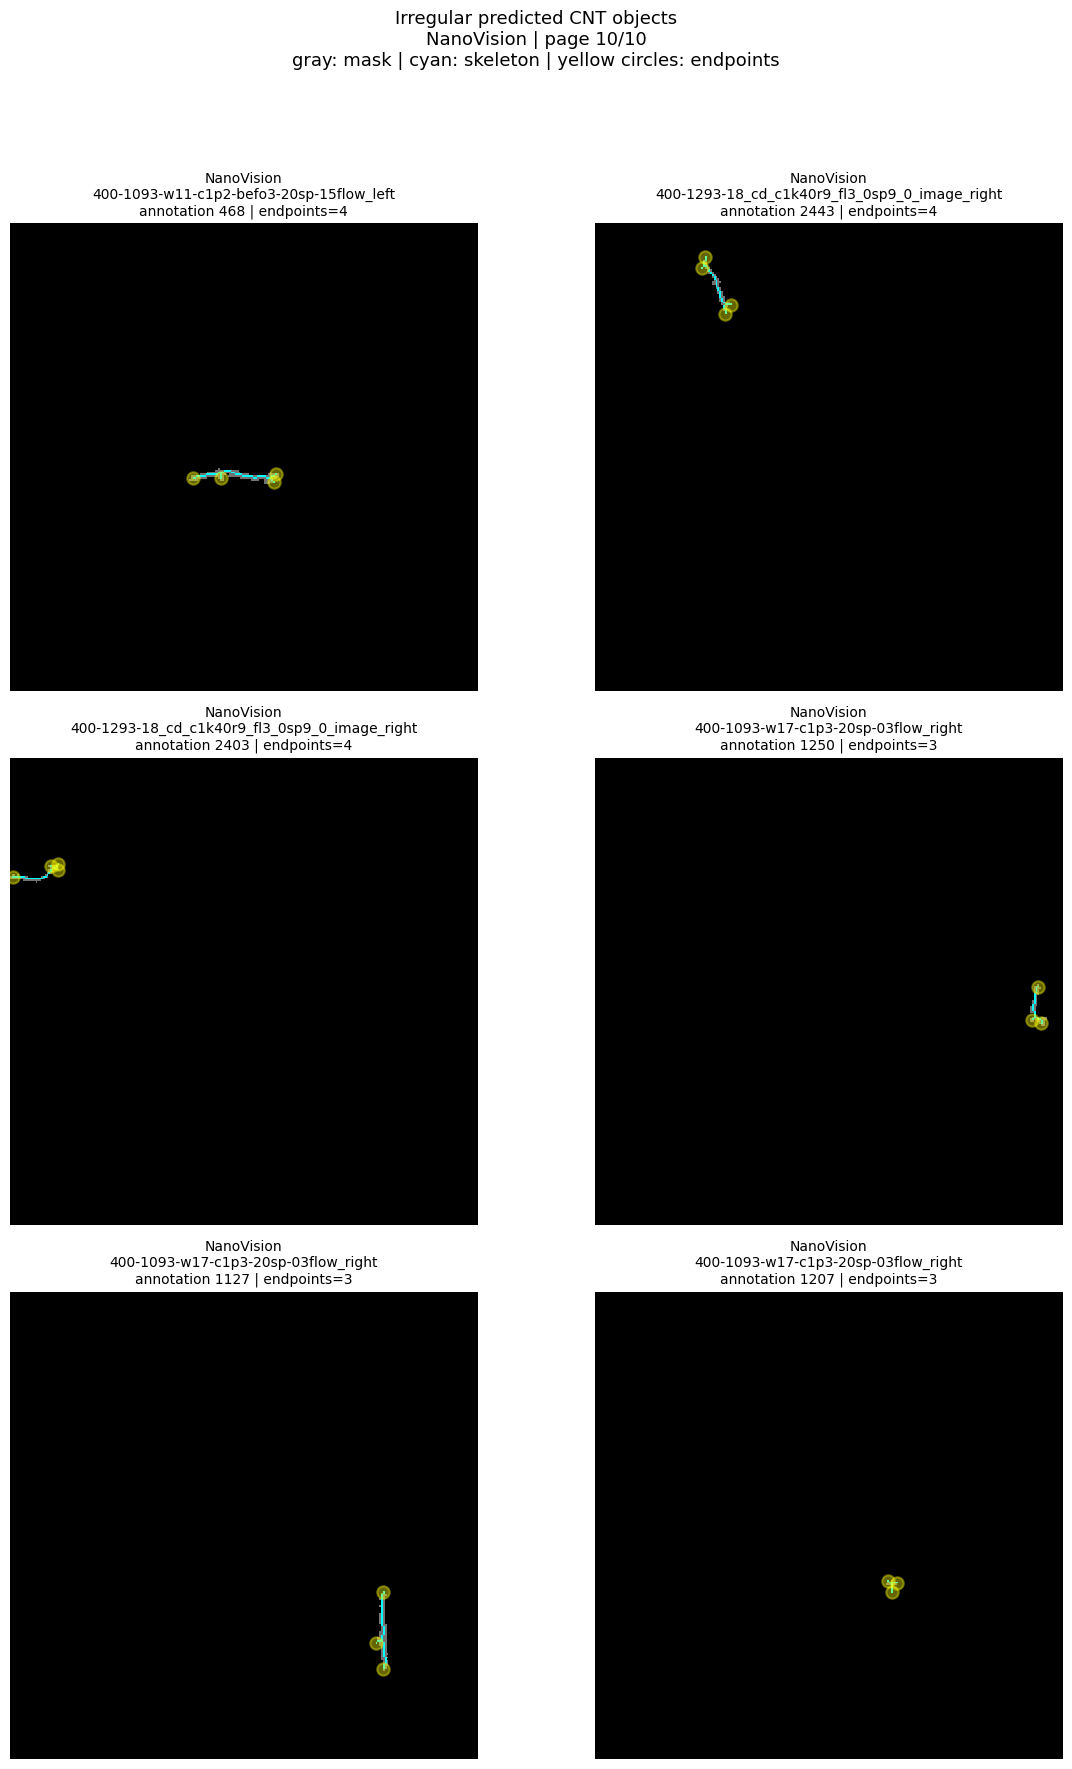

In [12]:
OBJECTS_PER_MODEL = 30
OBJECTS_PER_PAGE = 6
NUMBER_OF_COLUMNS = 2

selected_objects = (
    irregular_objects
    .sort_values(
        "endpoint_count",
        ascending=False,
    )
    .groupby(
        "model",
        group_keys=False,
    )
    .head(OBJECTS_PER_MODEL)
    .sort_values(
        [
            "model",
            "endpoint_count",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

print(
    selected_objects["model"]
    .value_counts()
)

number_of_pages = int(
    np.ceil(
        len(selected_objects)
        / OBJECTS_PER_PAGE
    )
)

for page_index in range(number_of_pages):
    page_objects = selected_objects.iloc[
        page_index * OBJECTS_PER_PAGE:
        (page_index + 1) * OBJECTS_PER_PAGE
    ]

    number_of_rows = int(
        np.ceil(
            len(page_objects)
            / NUMBER_OF_COLUMNS
        )
    )

    figure, axes = plt.subplots(
        number_of_rows,
        NUMBER_OF_COLUMNS,
        figsize=(
            12,
            6 * number_of_rows,
        ),
        squeeze=False,
    )

    axes = axes.ravel()

    for axis, row in zip(
        axes,
        page_objects.itertuples(
            index=False
        ),
    ):
        data = object_data[
            (
                row.model,
                int(row.annotation_id),
            )
        ]

        mask = data["mask"]
        skeleton = data["skeleton"]

        endpoint_coordinates = [
            tuple(coordinate)
            for coordinate in np.argwhere(
                skeleton
            )
            if (
                np.sum(
                    skeleton[
                        max(
                            0,
                            coordinate[0] - 1,
                        ):
                        coordinate[0] + 2,
                        max(
                            0,
                            coordinate[1] - 1,
                        ):
                        coordinate[1] + 2,
                    ]
                )
                - 1
                == 1
            )
        ]

        display_image = np.zeros(
            (*mask.shape, 3),
            dtype=float,
        )

        display_image[mask] = [
            0.45,
            0.45,
            0.45,
        ]

        display_image[skeleton] = [
            0.0,
            1.0,
            1.0,
        ]

        axis.imshow(
            display_image,
            interpolation="nearest",
        )

        if endpoint_coordinates:
            endpoint_rows = [
                coordinate[0]
                for coordinate
                in endpoint_coordinates
            ]

            endpoint_columns = [
                coordinate[1]
                for coordinate
                in endpoint_coordinates
            ]

            axis.scatter(
                endpoint_columns,
                endpoint_rows,
                s=80,
                marker="o",
                facecolor="yellow",
                edgecolor="yellow",
                linewidth=1.5,
                alpha=0.4,
            )

        axis.set_title(
            f"{row.model}\n"
            f"{Path(row.filename).stem}\n"
            f"annotation {row.annotation_id} | "
            f"endpoints={row.endpoint_count}",
            fontsize=10,
        )

        axis.axis("off")

    for axis in axes[
        len(page_objects):
    ]:
        axis.axis("off")

    models_on_page = ", ".join(
        page_objects["model"].unique()
    )

    figure.suptitle(
        f"Irregular predicted CNT objects\n"
        f"{models_on_page} | "
        f"page {page_index + 1}/{number_of_pages}\n"
        "gray: mask | cyan: skeleton | "
        "yellow circles: endpoints",
        fontsize=13,
    )

    figure.tight_layout(
        rect=[
            0,
            0,
            1,
            0.94,
        ]
    )

    plt.show()

# prune small branches

In [13]:
def find_irregular_predictions(
    json_path,
    model_name,
    *,
    min_branch_length_px=5,
):
    """
    Detect objects with more than two significant endpoints.

    Short terminal branches are removed before the final endpoint
    count is calculated.
    """
    coco = json.loads(
        json_path.read_text(
            encoding="utf-8-sig"
        )
    )

    images_by_id = {
        int(image["id"]): image
        for image in coco["images"]
    }

    rows = []
    object_data = {}

    for annotation in coco["annotations"]:
        image_id = int(
            annotation["image_id"]
        )

        annotation_id = int(
            annotation["id"]
        )

        image = images_by_id[image_id]

        height = int(image["height"])
        width = int(image["width"])

        mask = decode_annotation_mask(
            annotation,
            height,
            width,
        ).astype(bool)

        raw_skeleton = skeletonize(
            mask
        )

        raw_endpoint_count = count_endpoints(
            raw_skeleton
        )

        graph = skeleton_graph(
            raw_skeleton
        )

        pruned_graph = prune_branches(
            graph,
            min_length=min_branch_length_px,
        )

        pruned_skeleton = np.zeros_like(
            raw_skeleton,
            dtype=bool,
        )

        for row, column in pruned_graph.nodes:
            pruned_skeleton[
                row,
                column,
            ] = True

        pruned_endpoint_count = sum(
            pruned_graph.degree[node] == 1
            for node in pruned_graph
        )

        if pruned_endpoint_count <= 2:
            continue

        object_key = (
            model_name,
            annotation_id,
        )

        rows.append(
            {
                "model": model_name,
                "filename": image["file_name"],
                "image_id": image_id,
                "annotation_id": annotation_id,
                "score": annotation.get(
                    "score",
                    np.nan,
                ),
                "area_px": int(mask.sum()),
                "skeleton_pixels_before_pruning": int(
                    raw_skeleton.sum()
                ),
                "skeleton_pixels_after_pruning": int(
                    pruned_skeleton.sum()
                ),
                "raw_endpoint_count": (
                    raw_endpoint_count
                ),
                "endpoint_count": (
                    pruned_endpoint_count
                ),
                "removed_endpoint_count": (
                    raw_endpoint_count
                    - pruned_endpoint_count
                ),
            }
        )

        object_data[object_key] = {
            "mask": mask,
            "raw_skeleton": raw_skeleton,
            "skeleton": pruned_skeleton,
            "graph": pruned_graph,
        }

    return rows, object_data

In [17]:
MIN_BRANCH_LENGTH_PX = 5

cpsam_rows, cpsam_data = (
    find_irregular_predictions(
        CPSAM_RLE_JSON,
        "CPSAM v2",
        min_branch_length_px=(
            MIN_BRANCH_LENGTH_PX
        ),
    )
)

nanovision_rows, nanovision_data = (
    find_irregular_predictions(
        NANOVISION_RLE_JSON,
        "NanoVision",
        min_branch_length_px=(
            MIN_BRANCH_LENGTH_PX
        ),
    )
)

irregular_objects = pd.DataFrame(
    cpsam_rows + nanovision_rows
)

object_data = {
    **cpsam_data,
    **nanovision_data,
}

print(
    "Minimum retained terminal-branch length:",
    MIN_BRANCH_LENGTH_PX,
    "pixels",
)

print(
    "Irregular objects after pruning:",
    len(irregular_objects),
)

display(irregular_objects.head())

Minimum retained terminal-branch length: 5 pixels
Irregular objects after pruning: 167


,model,filename,image_id,annotation_id,score,area_px,skeleton_pixels_before_pruning,skeleton_pixels_after_pruning,raw_endpoint_count,endpoint_count,removed_endpoint_count
0,CPSAM v2,1293-22_3_2_20230306222551.tif,1,32,NaN,196,43,40,4,3,1
1,CPSAM v2,1293-22_3_2_20230306222551.tif,1,47,NaN,438,103,103,3,3,0
2,CPSAM v2,1293-22_3_2_20230306222551.tif,1,50,NaN,156,39,39,3,3,0
3,CPSAM v2,1293-22_3_2_20230306222551.tif,1,71,NaN,321,70,70,3,3,0
4,CPSAM v2,1293-22_3_2_20230306222551.tif,1,73,NaN,354,79,79,3,3,0


## Number of irregular objects after pruning
Count the objects that still have more than two endpoints after
removing terminal branches shorter than the selected threshold.

In [19]:
total_predictions = {
    "CPSAM v2": len(
        json.loads(
            CPSAM_RLE_JSON.read_text(
                encoding="utf-8-sig"
            )
        )["annotations"]
    ),
    "NanoVision": len(
        json.loads(
            NANOVISION_RLE_JSON.read_text(
                encoding="utf-8-sig"
            )
        )["annotations"]
    ),
}

irregular_after_pruning = (
    irregular_objects
    .groupby("model")
    .agg(
        irregular_objects=(
            "annotation_id",
            "count",
        ),
        affected_images=(
            "filename",
            "nunique",
        ),
        mean_endpoint_count=(
            "endpoint_count",
            "mean",
        ),
        maximum_endpoint_count=(
            "endpoint_count",
            "max",
        ),
    )
    .reindex(
        [
            "CPSAM v2",
            "NanoVision",
        ],
        fill_value=0,
    )
)

irregular_after_pruning[
    "total_predictions"
] = pd.Series(total_predictions)

irregular_after_pruning[
    "irregular_percentage"
] = (
    100
    * irregular_after_pruning[
        "irregular_objects"
    ]
    / irregular_after_pruning[
        "total_predictions"
    ]
)

print(
    "Minimum branch length:",
    MIN_BRANCH_LENGTH_PX,
    "pixels",
)

display(irregular_after_pruning)

Minimum branch length: 5 pixels


,irregular_objects,affected_images,mean_endpoint_count,maximum_endpoint_count,total_predictions,irregular_percentage
model,,,,,,
CPSAM v2,165,24,3.224242,6,2853,5.783386
NanoVision,2,2,3.500000,4,3849,0.051962


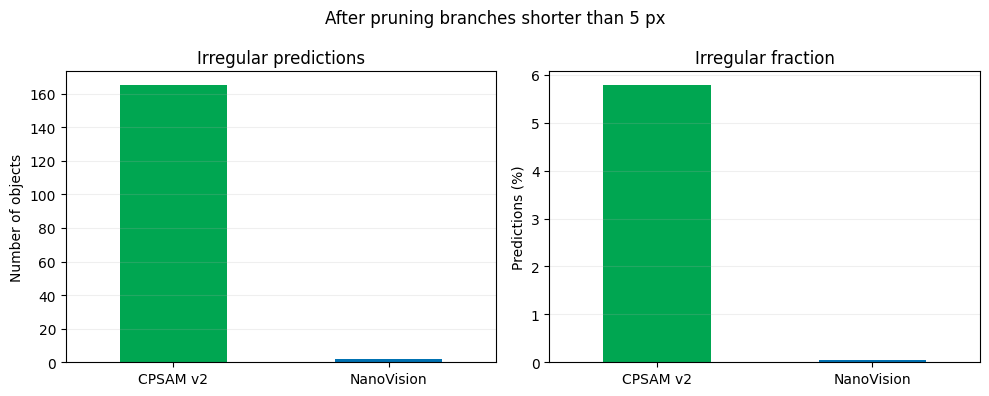

In [21]:
# %%
figure, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

irregular_after_pruning[
    "irregular_objects"
].plot.bar(
    ax=axes[0],
    color=[
        "#00A651",
        "#0072B2",
    ],
)

irregular_after_pruning[
    "irregular_percentage"
].plot.bar(
    ax=axes[1],
    color=[
        "#00A651",
        "#0072B2",
    ],
)

axes[0].set_ylabel("Number of objects")
axes[0].set_title(
    "Irregular predictions"
)

axes[1].set_ylabel("Predictions (%)")
axes[1].set_title(
    "Irregular fraction"
)

for axis in axes:
    axis.set_xlabel("")
    axis.tick_params(
        axis="x",
        rotation=0,
    )
    axis.grid(
        axis="y",
        alpha=0.2,
    )

figure.suptitle(
    f"After pruning branches shorter than "
    f"{MIN_BRANCH_LENGTH_PX} px"
)

figure.tight_layout()
plt.show()

model
CPSAM v2      30
NanoVision     2
Name: count, dtype: int64


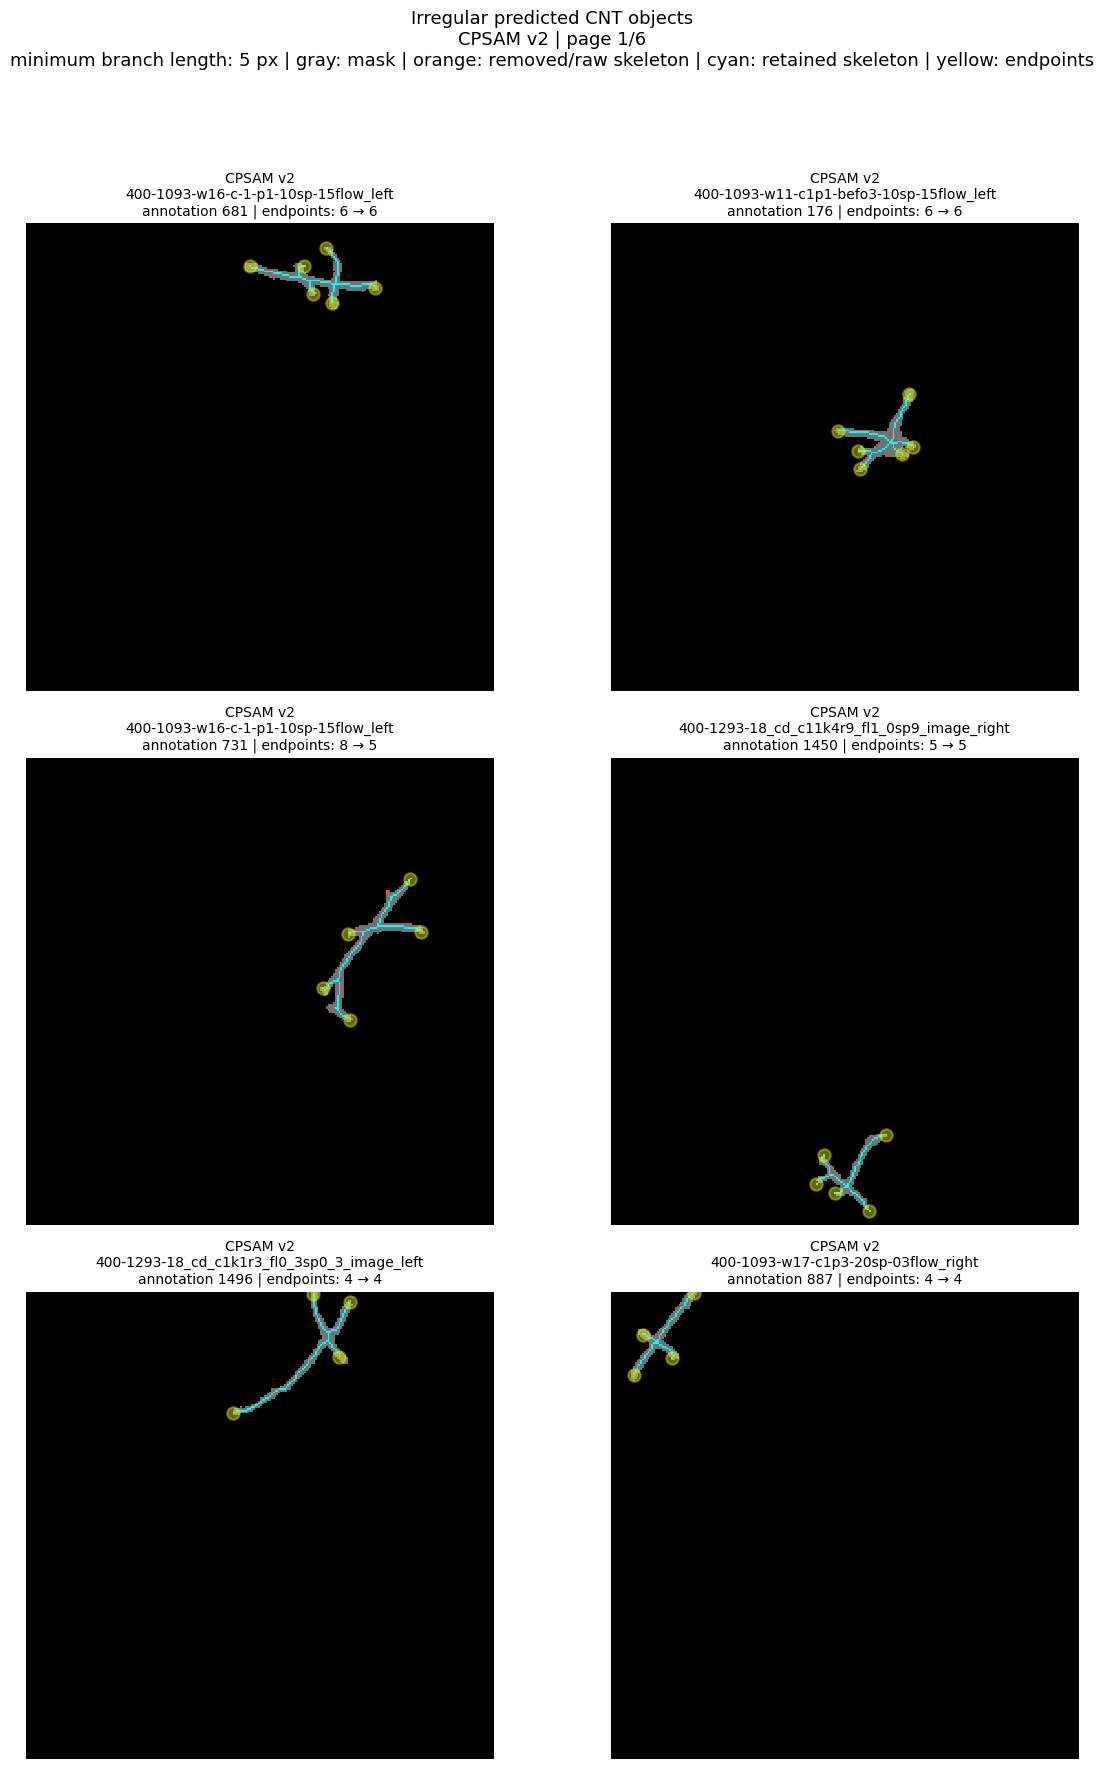

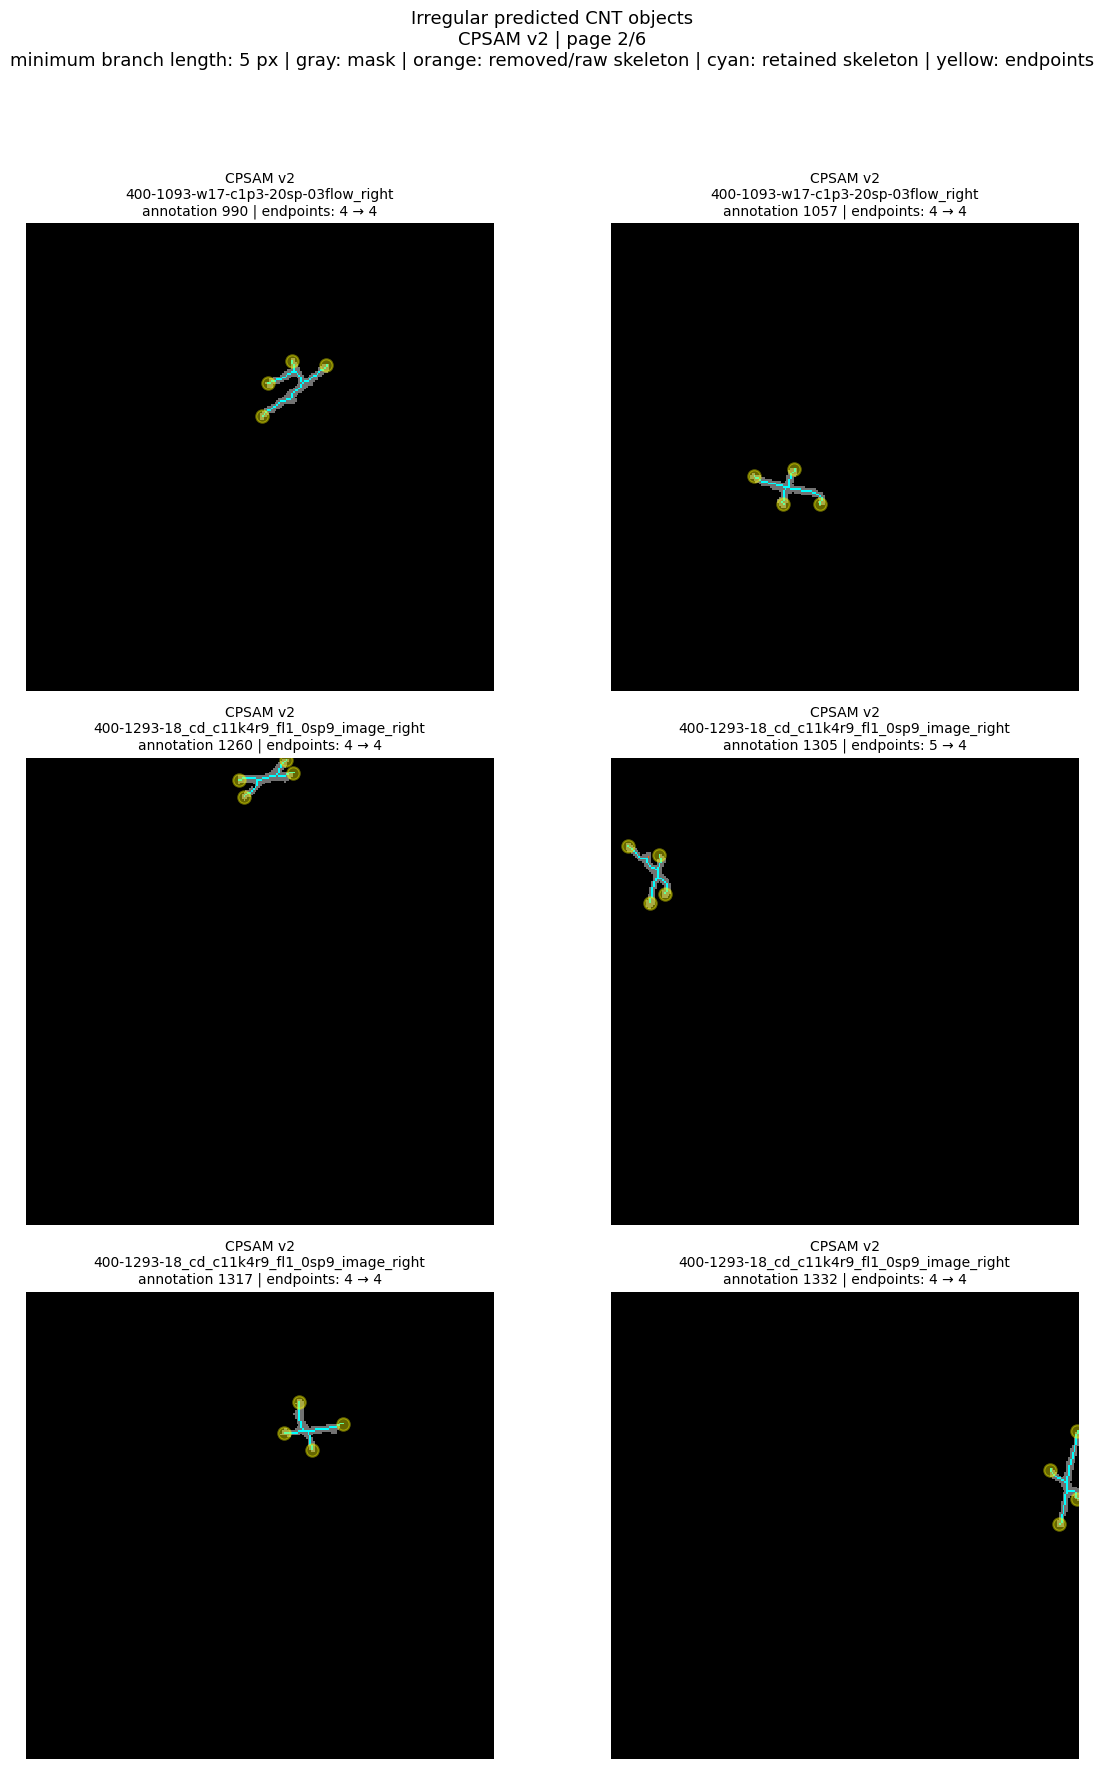

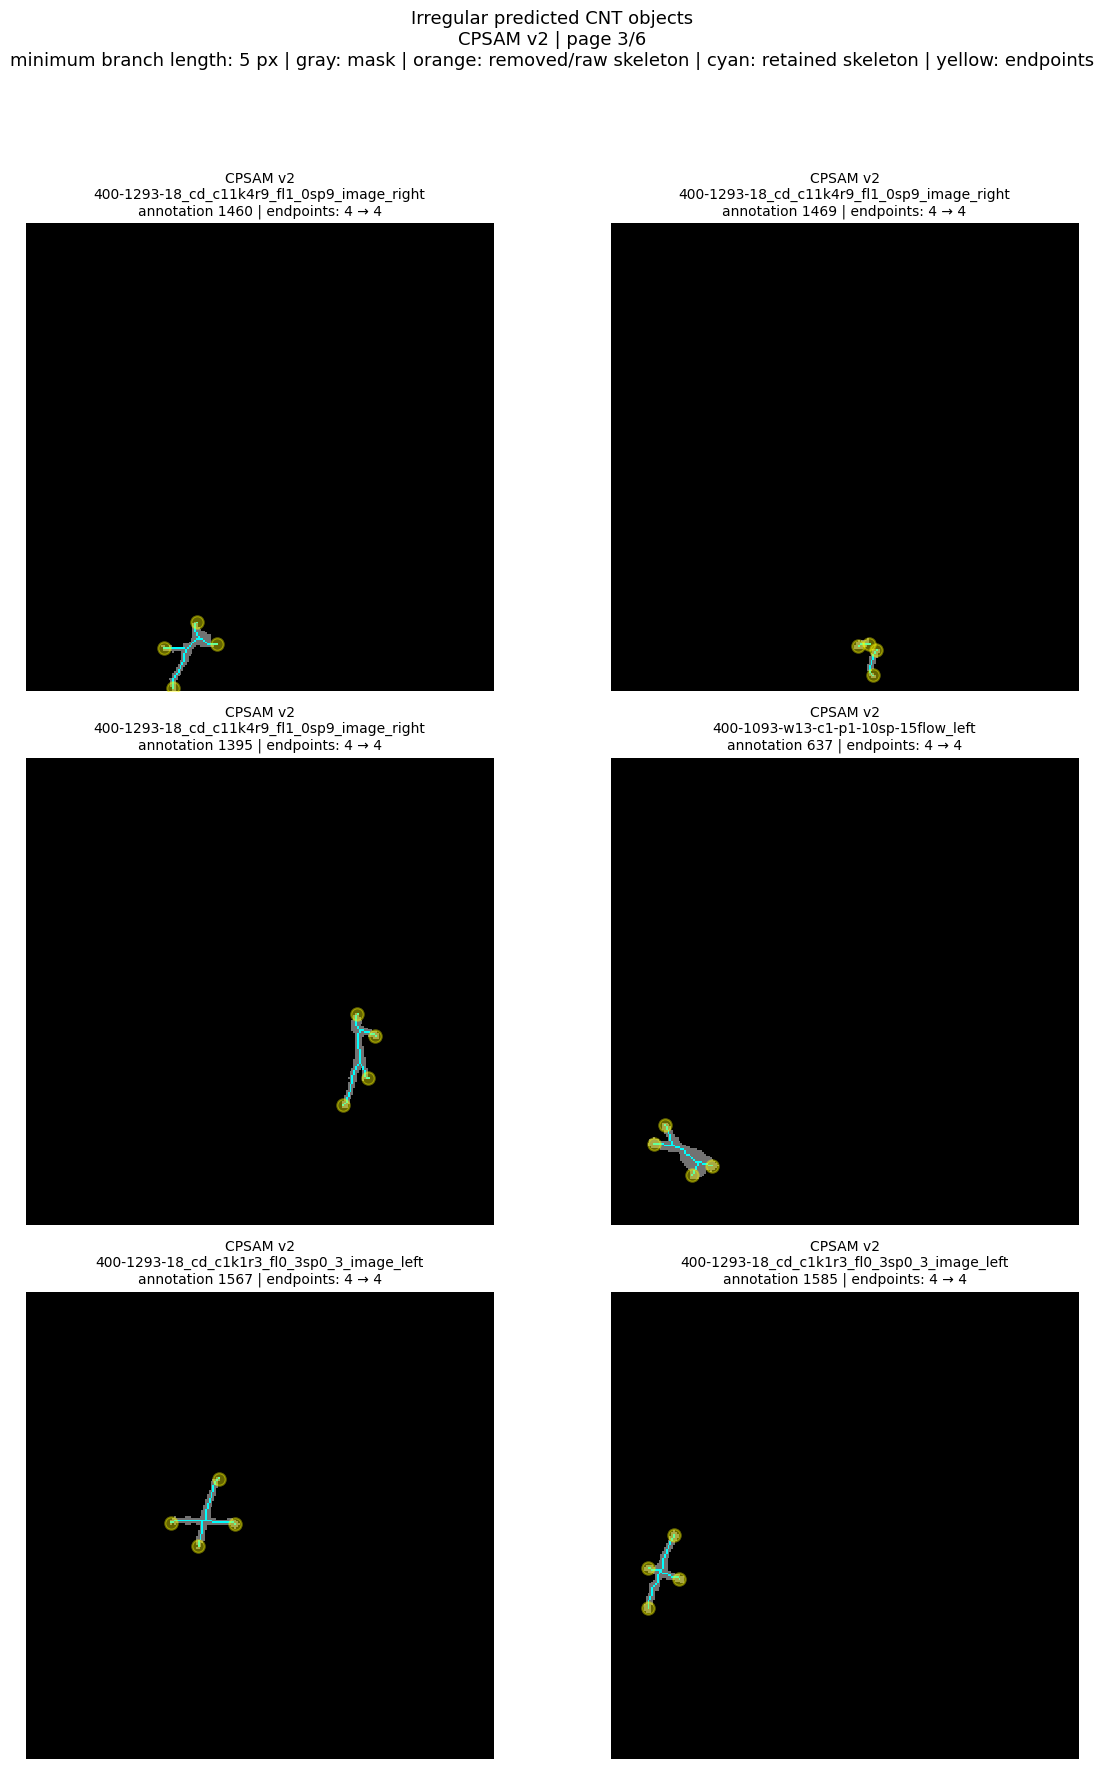

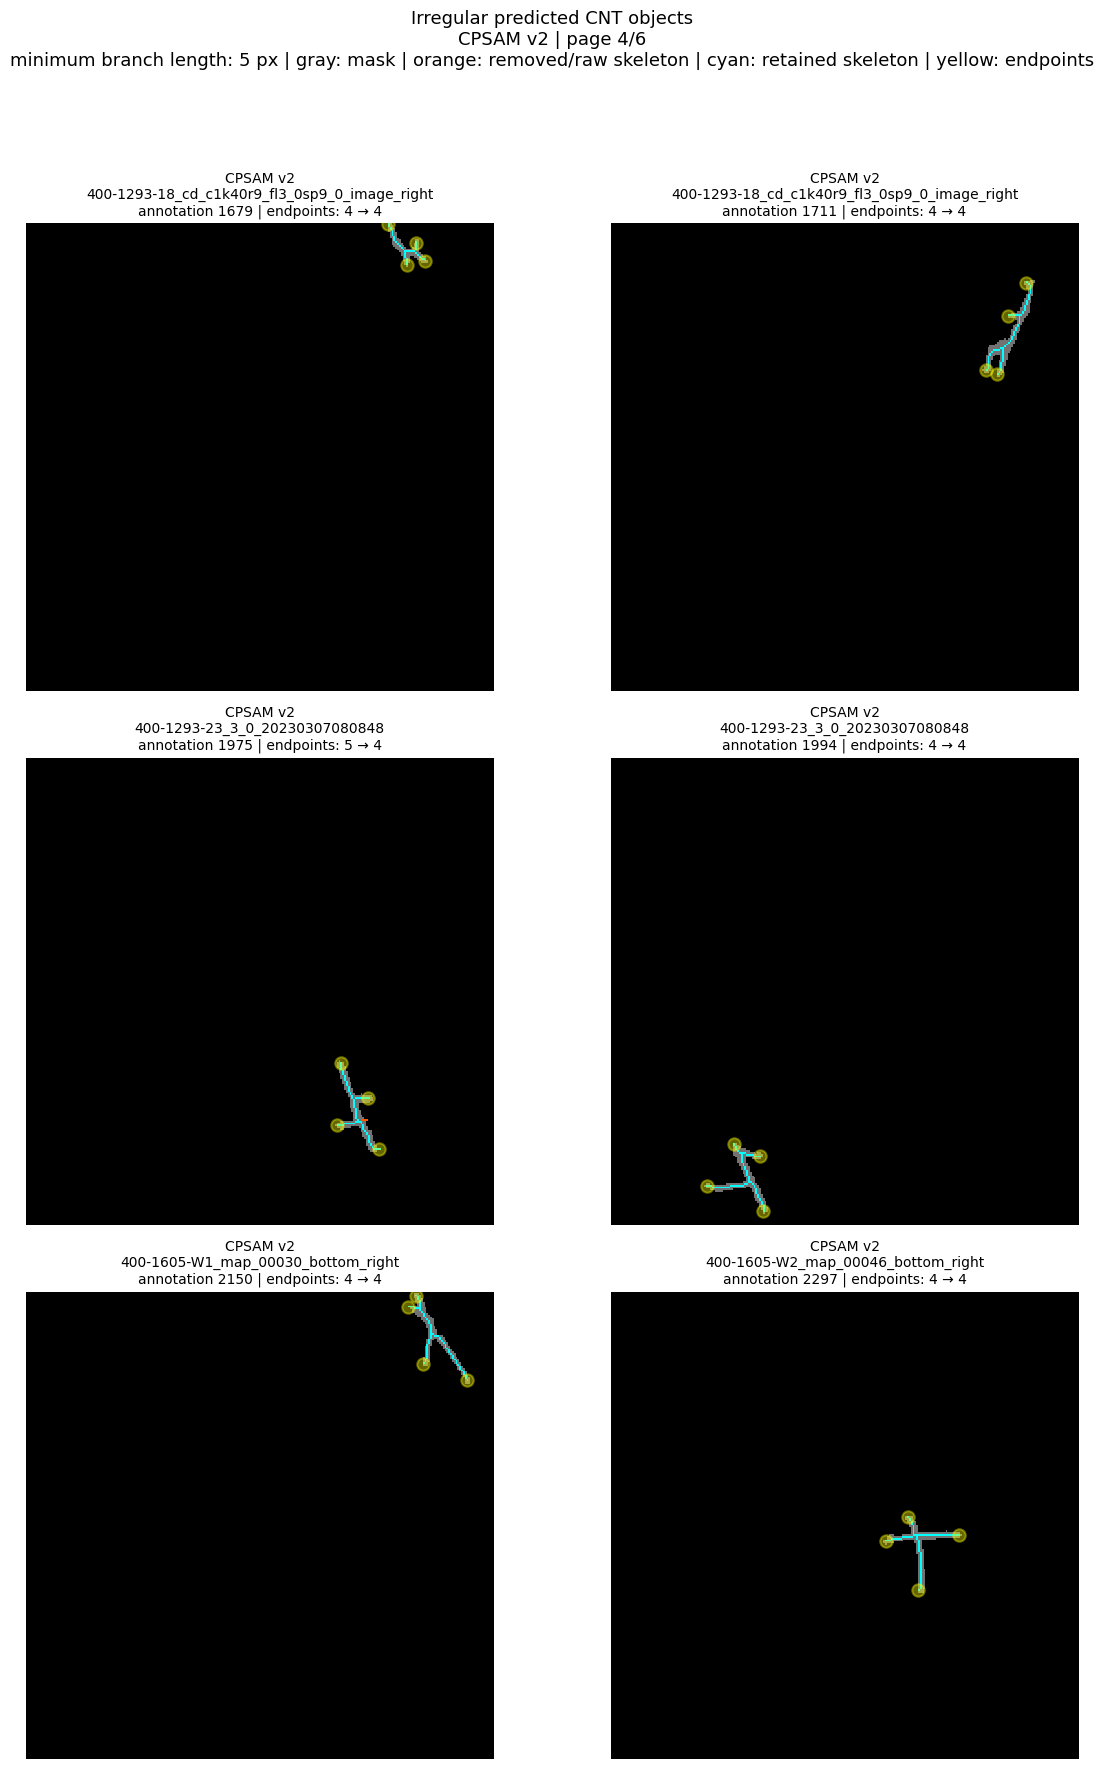

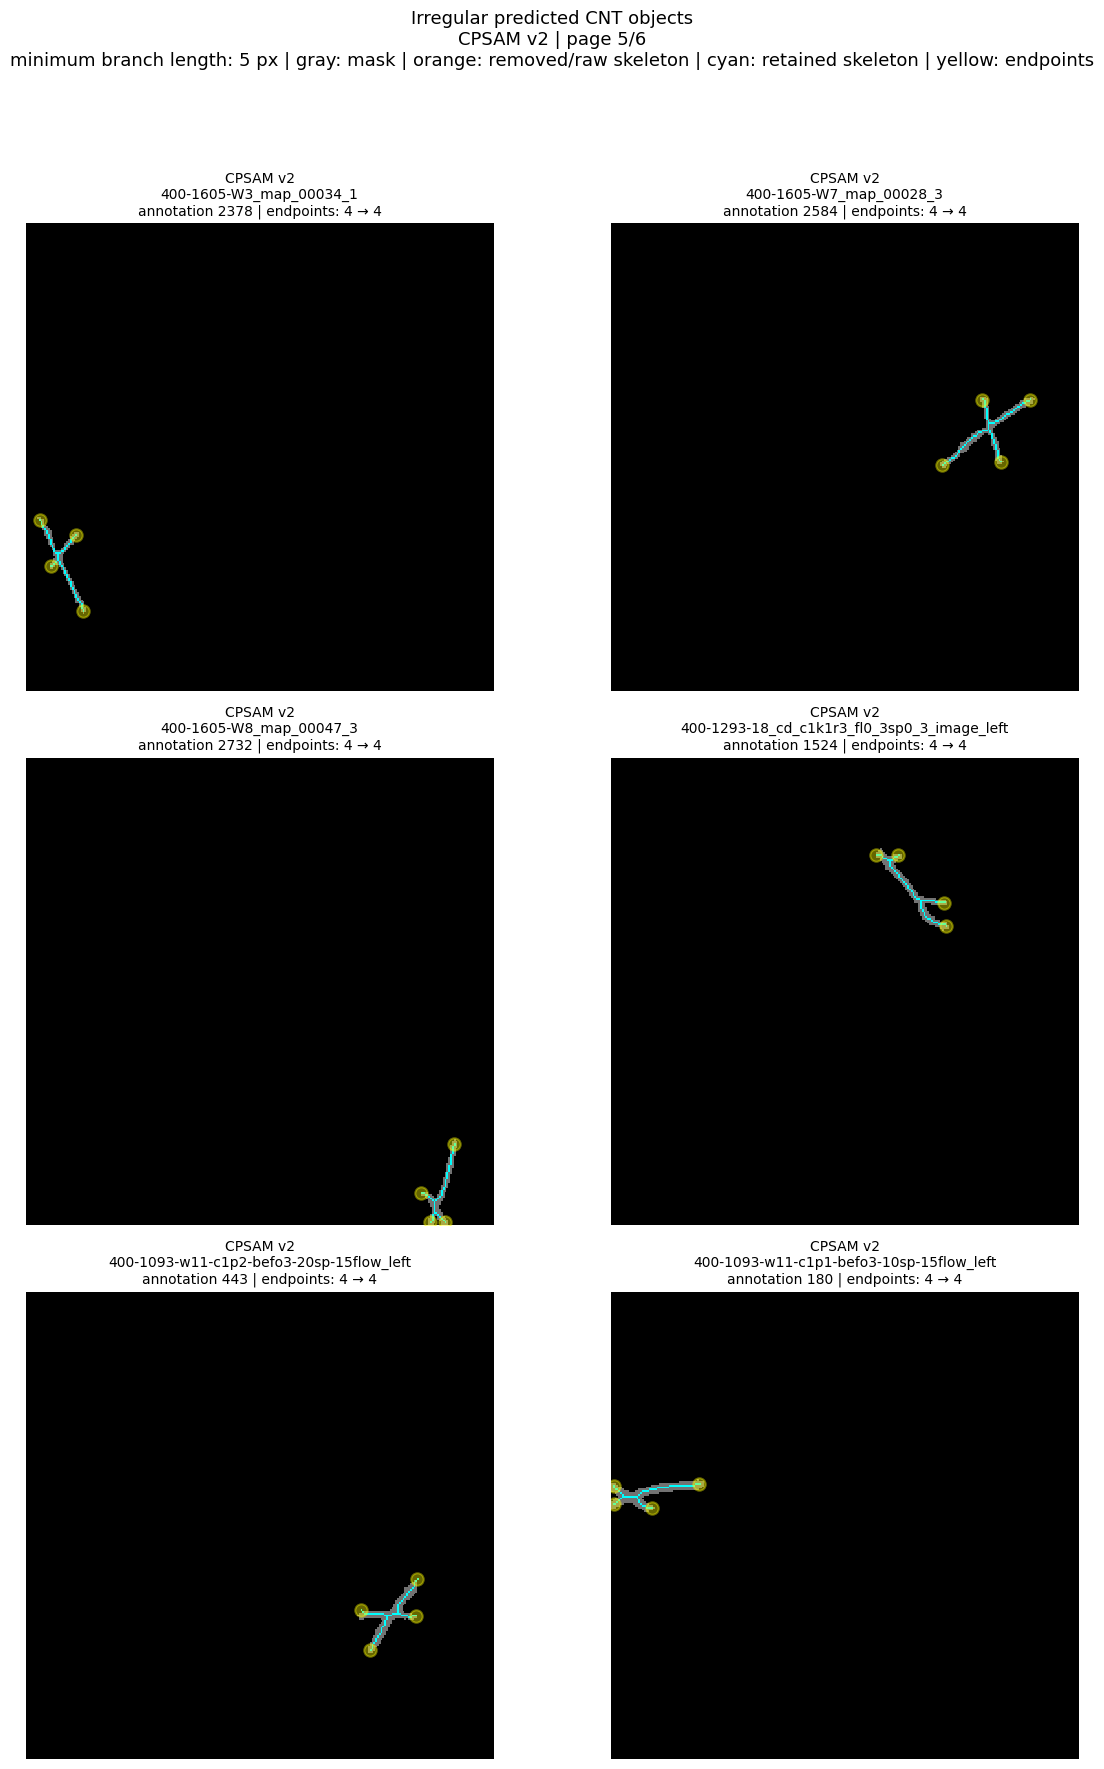

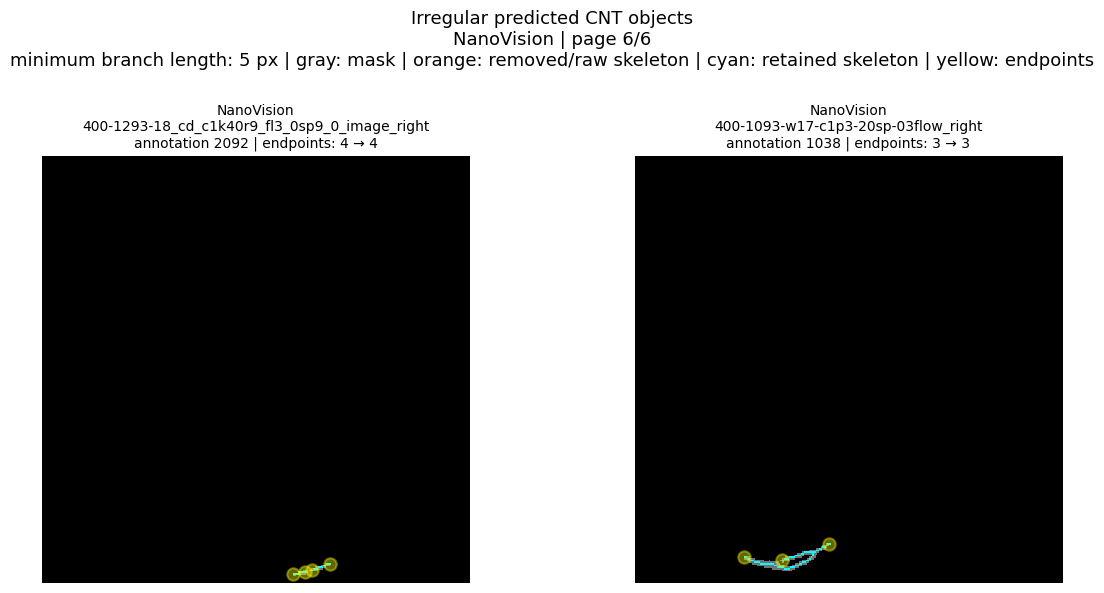

In [18]:
OBJECTS_PER_MODEL = 30
OBJECTS_PER_PAGE = 6
NUMBER_OF_COLUMNS = 2

selected_objects = (
    irregular_objects
    .sort_values(
        "endpoint_count",
        ascending=False,
    )
    .groupby(
        "model",
        group_keys=False,
    )
    .head(OBJECTS_PER_MODEL)
    .sort_values(
        [
            "model",
            "endpoint_count",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

print(
    selected_objects["model"]
    .value_counts()
)

number_of_pages = int(
    np.ceil(
        len(selected_objects)
        / OBJECTS_PER_PAGE
    )
)

for page_index in range(number_of_pages):
    page_objects = selected_objects.iloc[
        page_index * OBJECTS_PER_PAGE:
        (page_index + 1) * OBJECTS_PER_PAGE
    ]

    number_of_rows = int(
        np.ceil(
            len(page_objects)
            / NUMBER_OF_COLUMNS
        )
    )

    figure, axes = plt.subplots(
        number_of_rows,
        NUMBER_OF_COLUMNS,
        figsize=(
            12,
            6 * number_of_rows,
        ),
        squeeze=False,
    )

    axes = axes.ravel()

    for axis, row in zip(
        axes,
        page_objects.itertuples(
            index=False
        ),
    ):
        data = object_data[
            (
                row.model,
                int(row.annotation_id),
            )
        ]

        mask = data["mask"]
        raw_skeleton = data["raw_skeleton"]
        skeleton = data["skeleton"]

        endpoint_coordinates = [
            tuple(coordinate)
            for coordinate in np.argwhere(
                skeleton
            )
            if (
                np.sum(
                    skeleton[
                        max(
                            0,
                            coordinate[0] - 1,
                        ):
                        coordinate[0] + 2,
                        max(
                            0,
                            coordinate[1] - 1,
                        ):
                        coordinate[1] + 2,
                    ]
                )
                - 1
                == 1
            )
        ]

        display_image = np.zeros(
            (*mask.shape, 3),
            dtype=float,
        )

        display_image[mask] = [
            0.45,
            0.45,
            0.45,
        ]

        display_image[raw_skeleton] = [
            1.0,
            0.35,
            0.0,
        ]

        display_image[skeleton] = [
            0.0,
            1.0,
            1.0,
        ]

        axis.imshow(
            display_image,
            interpolation="nearest",
        )

        if endpoint_coordinates:
            endpoint_rows = [
                coordinate[0]
                for coordinate
                in endpoint_coordinates
            ]

            endpoint_columns = [
                coordinate[1]
                for coordinate
                in endpoint_coordinates
            ]

            axis.scatter(
                endpoint_columns,
                endpoint_rows,
                s=80,
                marker="o",
                facecolor="yellow",
                edgecolor="yellow",
                linewidth=1.5,
                alpha=0.4,
            )

        axis.set_title(
            f"{row.model}\n"
            f"{Path(row.filename).stem}\n"
            f"annotation {row.annotation_id} | "
            f"endpoints: {row.raw_endpoint_count}"
            f" → {row.endpoint_count}",
            fontsize=10,
        )

        axis.axis("off")

    for axis in axes[
        len(page_objects):
    ]:
        axis.axis("off")

    models_on_page = ", ".join(
        page_objects["model"].unique()
    )

    figure.suptitle(
        f"Irregular predicted CNT objects\n"
        f"{models_on_page} | "
        f"page {page_index + 1}/{number_of_pages}\n"
        f"minimum branch length: "
        f"{MIN_BRANCH_LENGTH_PX} px | "
        "gray: mask | orange: removed/raw skeleton | "
        "cyan: retained skeleton | yellow: endpoints",
        fontsize=13,
    )

    figure.tight_layout(
        rect=[
            0,
            0,
            1,
            0.94,
        ]
    )

    plt.show()